In [1]:
import pandas as pd
import os
import random
import chardet
import requests
import json
import numpy as np
from urllib3.util.retry import Retry
import openai
from requests.adapters import HTTPAdapter
import os
import pickle
import matplotlib.pyplot as plt
from utils.read_group_danmu import read_group_danmu

def time_series_permutation_test(x, y, n_permutations=10000, random_state=42):
    """
    Compute Pearson's r and a two-sided circular-shift permutation p-value.

    Circular shifts break the time alignment between two series while preserving
    each series' values and autocorrelation structure. For 2-D inputs, matching
    columns are tested pairwise.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if x.shape != y.shape:
        raise ValueError("x and y must have the same shape")

    if x.ndim == 2:
        results = [
            time_series_permutation_test(
                x[:, i], y[:, i],
                n_permutations=n_permutations,
                random_state=random_state
            )
            for i in range(x.shape[1])
        ]
        r_values, p_values = zip(*results)
        return np.asarray(r_values), np.asarray(p_values)

    if x.ndim != 1:
        raise ValueError("x and y must be 1-D or 2-D arrays")

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if x.size < 3 or np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan

    r_observed = float(np.corrcoef(x, y)[0, 1])

    x_unit = (x - np.mean(x)) / np.sqrt(np.sum((x - np.mean(x)) ** 2))
    y_unit = (y - np.mean(y)) / np.sqrt(np.sum((y - np.mean(y)) ** 2))
    circular_r = np.fft.ifft(
        np.conj(np.fft.fft(x_unit)) * np.fft.fft(y_unit)
    ).real

    possible_shifts = np.arange(1, x.size)
    n_permutations = min(int(n_permutations), possible_shifts.size)
    if n_permutations < 1:
        raise ValueError("n_permutations must be at least 1")

    if n_permutations == possible_shifts.size:
        shifts = possible_shifts
    else:
        rng = np.random.default_rng(random_state)
        shifts = rng.choice(possible_shifts, size=n_permutations, replace=False)

    null_r = circular_r[shifts]
    p_value = (np.sum(np.abs(null_r) >= abs(r_observed)) + 1) / (null_r.size + 1)
    return r_observed, float(p_value)

### Cross-language

In [2]:
def read_scores(file, language='Chinese'):
    file_name = file.split('.')[0]
    with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-BilingualAnimes\Processed_danmu\%s\danmu_%s_downsample.pkl' % (language, file_name), 'rb') as f:
        danmu_dict = pickle.load(f)
    time_ranges = danmu_dict['%s_time_range' % file]
    
    time_points = np.zeros(len(time_ranges))
    for i in range(len(time_points)):
        time_points[i] = np.mean(time_ranges[i])

    datadir = os.path.join(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-BilingualAnimes\Emotion_scores', language, file_name)
    file_names2 = os.listdir(datadir)
    n_files = len(file_names2)
    # if n_files != seg_count:
    #     Warning('The number of files is not equal to segment counts!')
    #     print('n_files:', n_files, 'seg_count:', seg_count)
    scores_all = np.zeros((n_files, 6))
    for count in range(n_files):
        # print(count)
        file_score = '%.3f_%.3f.json' % (time_ranges[count][0], time_ranges[count][1])
        with open(os.path.join(datadir, file_score), 'r', encoding='utf-8') as file_score:
            data = json.load(file_score)            

        # 提取 "content" 字段中的文本
        content = data['choices'][0]['message']['content']

        # 解析文本，将情绪评分提取到列表中
        if language=='Chinese':
            emotions = ["高兴", "惊讶", "悲伤", "愤怒", "厌恶", "恐惧"]
        elif language=='Japanese':
            emotions = ["嬉しさ", "驚き", "悲しみ", "怒り", "嫌悪", "恐れ"]
        scores = []

        # 拆分 content 字符串，并提取每个情绪的评分
        for emotion in emotions:
            start = content.find(emotion) + len(emotion) + 2
            end = content.find(";", start)
            if end == -1:  # 最后一个情绪评分后没有分号
                end = len(content)
            # score = int(content[start:end].strip().rstrip('.'))
            # score = int(content[start:end].strip())
            try:
                score = float(content[start:end].strip())
            except:
                if content[start] == '[':
                    score = float(content[start+1:end-1].strip())
                else:
                    score = float(content[start:end].strip()[:-1])
            scores.append(score)
            
        scores_all[count] = np.array(scores)
        
    return scores_all, time_points, time_ranges

def smooth_scores(preds, time_points, smooth_win=10):
    half_win = int(round(smooth_win/2))
    preds_smoothed = np.zeros(preds.shape)
    for i in range(preds.shape[0]):
        preds_smoothed[i,:] = np.mean(preds[abs(time_points[:preds.shape[0]] - time_points[:preds.shape[0]][i]) <= half_win, :], axis=0)
    return preds_smoothed

def smooth_scores_resample(preds, time_points, smooth_win=10, resample_fs=2):
    half_win = int(round(smooth_win/2))
    resample_times = np.arange(0, np.ceil(np.max(time_points)), resample_fs)
    preds_smoothed = np.zeros((len(resample_times), preds.shape[1]))
    for i in range(len(resample_times)):
        if np.sum(abs(time_points - resample_times[i]) <= half_win)==0:
            preds_smoothed[i,:] = preds_smoothed[i-1,:]
        else:
            if len(preds[abs(time_points - resample_times[i]) <= half_win, :].shape) == 1:
                preds_smoothed[i,:] = np.mean(preds[abs(time_points - resample_times[i]) <= half_win, :].unsqueeze(0), axis=0)
            else:
                preds_smoothed[i,:] = np.mean(preds[abs(time_points - resample_times[i]) <= half_win, :], axis=0)
    return preds_smoothed, resample_times
        

def plot_scores(preds_smoothed, time_points):
    colors = ['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']
    emos = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]

    plt.figure(figsize=(15, 12))
    for j in range(6):
        plt.subplot(6,1,j+1)
        plt.plot(time_points[:preds_smoothed.shape[0]], preds_smoothed[:,j], color=colors[j], linewidth=0.7)
        plt.xlim([0,max(time_points)])
        plt.ylim([0,7])
        plt.ylabel('Scores')
        plt.xlabel('Time/s')
        plt.title(emos[j])

    # 调整布局
    plt.tight_layout()
    # plt.savefig('figures/prompt_v4_gpt4o_longMovie_lineplot.jpg', dpi=300)
    plt.show()
    

def plot_scores2(preds_smoothed, preds_smoothed2):
    colors = ['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']
    emos = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]

    vertical_gap_small = 0.001
    vertical_gap_large = 0.1
    height = 0.056
    left1 = 0.05
    right1 = 0.97
    width = right1 - left1

    fig = plt.figure(figsize=(8, 6))

    for j in range(6):
        bottom1 = 1 - (j+1)*height*2 - j*vertical_gap_large
        bottom2 = bottom1 + height
        R, p_perm = time_series_permutation_test(preds_smoothed[:,j], preds_smoothed2[:,j])
        
        ax1 = fig.add_axes([left1, bottom2, width, height])
        ax1.plot(np.arange(preds_smoothed.shape[0])*2, preds_smoothed[:, j], color=colors[j], linewidth=0.7)
        ax1.set_ylim([0, 7])
        ax1.set_xlim([0,preds_smoothed.shape[0]*2])
        ax1.set_title(emos[j]+' (R = %.3f)' % R, fontsize=13)
        ax1.set_yticks([0,4], [0,4], fontsize=10)
        ax1.set_xticks([])
        ax1.set_ylabel('Chinese', fontsize=10, rotation=0, labelpad=25)
        ax1.yaxis.label.set_position((0, 0.3))
        
        ax1.spines['right'].set_visible(False)
        ax1.spines['top'].set_visible(False)
        
        ax2 = fig.add_axes([left1, bottom1, width, height])
        ax2.plot(np.arange(preds_smoothed.shape[0])*2, preds_smoothed2[:, j], color=colors[j], linewidth=0.7)
        ax2.set_ylim([0, 7])
        ax2.set_xlim([0,preds_smoothed.shape[0]*2])
        # ax2.set_title(emos[j], fontsize=15)
        ax2.set_yticks([0,4], [0,4], fontsize=10)
        ax2.set_xticks([])
        ax2.set_ylabel('Japanese', fontsize=10, rotation=0, labelpad=25)
        ax2.yaxis.label.set_position((0, 0.3))
        
        ax2.spines['right'].set_visible(False)
        # ax2.spines['top'].set_visible(False)
        
    ax2.set_xlabel('Time/s', fontsize=12)
    ax2.set_xticks(np.arange(0,preds_smoothed.shape[0]*2,500), np.arange(0,preds_smoothed.shape[0]*2,500), fontsize=12)

    plt.tight_layout()
    # plt.savefig('figures/prompt_v4_gpt3_5_turbo_Chin_Japa_lineplot_aligned.jpg', dpi=300, bbox_inches='tight')
    plt.show()

In [3]:
# Match time frames of the Japanese and Chinese versions

cut_indices = {}
cut_indices[1] = [np.arange(9*60+58, 10*60+8), 0]
cut_indices[2] = [np.arange(16*60+50, 16*60+60), 0]
cut_indices[3] = [np.arange(18*60+28, 19*60+15), 8]
cut_indices[4] = [np.arange(22*60+11, 22*60+41), 9]
cut_indices[5] = [np.arange(11*60+37, 12*60+1), 3]
cut_indices[6] = [np.arange(14*60+26, 14*60+28), 10]
cut_indices[7] = [np.arange(0*60+48, 0*60+57), 10]
cut_indices[8] = [np.arange(17*60+52, 17*60+56), 10]
cut_indices[9] = [np.arange(22*60+25, 22*60+47), 10]
cut_indices[10] = [np.arange(16*60+37, 17*60+39), 12]
cut_indices[11] = [np.arange(19*60+46, 19*60+57), 15]

In [4]:
cut_len = 0
cut_len_chin_more = 0
for i in range(1,12):
    cut_len += cut_indices[i][0][-1] - cut_indices[i][0][0] + 10
    cut_len_chin_more += cut_indices[i][1]
print(cut_len)
print(cut_len_chin_more+cut_len)

330
417


Episode 1 1398


C:\Users\Windows\AppData\Local\Temp\ipykernel_27380\867449811.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


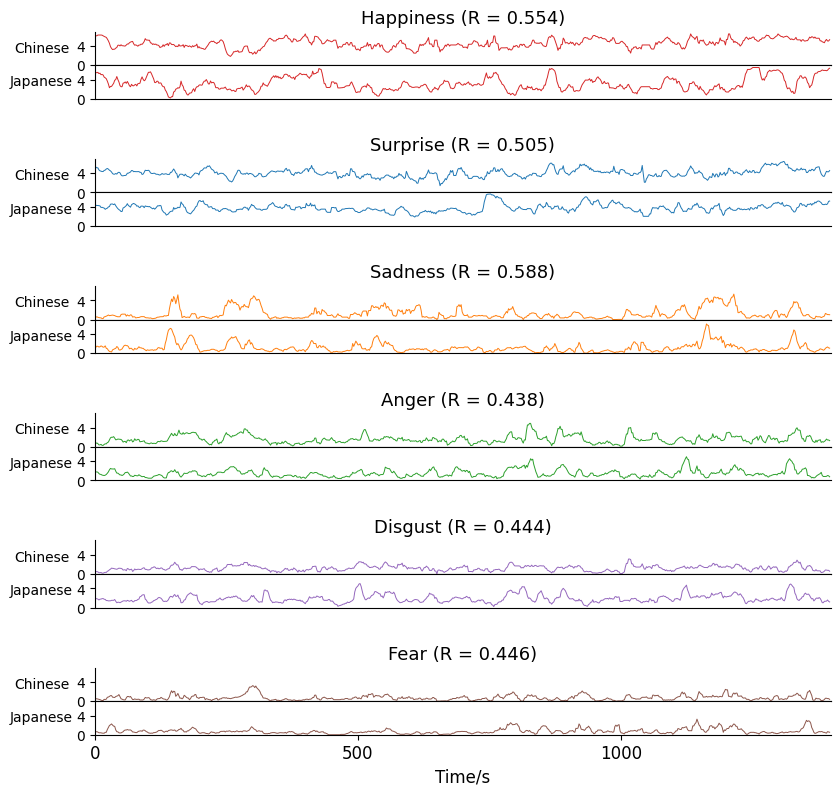

Episode 2 1396


C:\Users\Windows\AppData\Local\Temp\ipykernel_27380\867449811.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


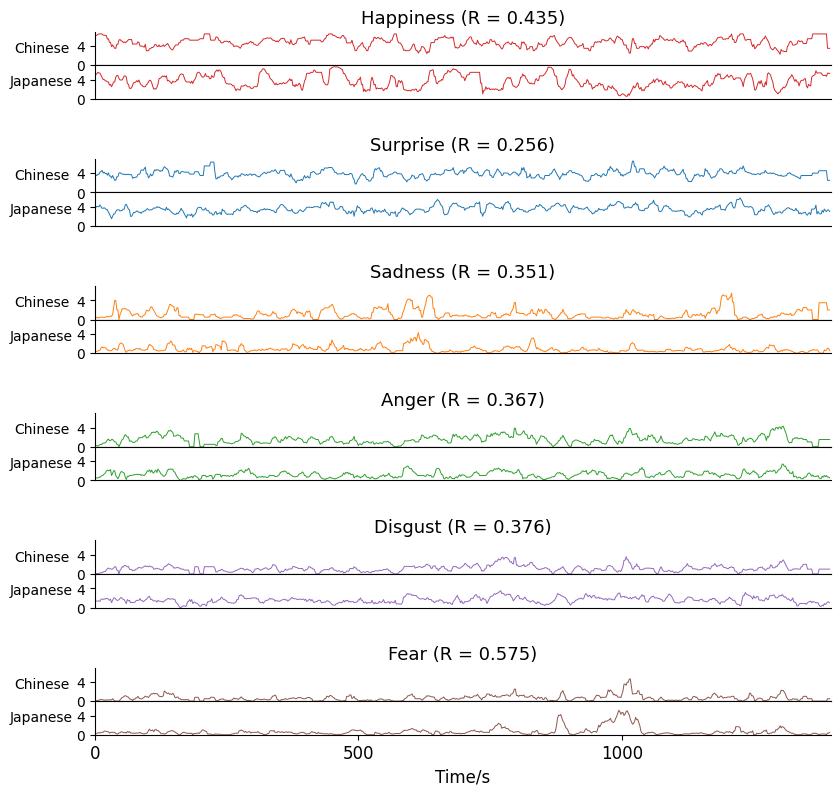

Episode 3 1348


C:\Users\Windows\AppData\Local\Temp\ipykernel_27380\867449811.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


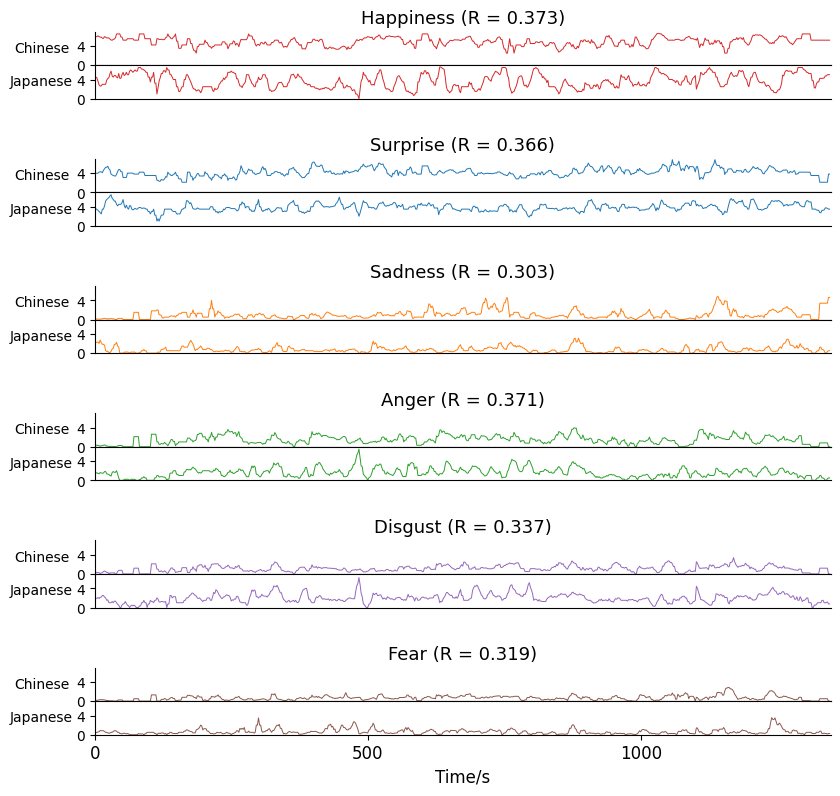

Episode 4 1372


C:\Users\Windows\AppData\Local\Temp\ipykernel_27380\867449811.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


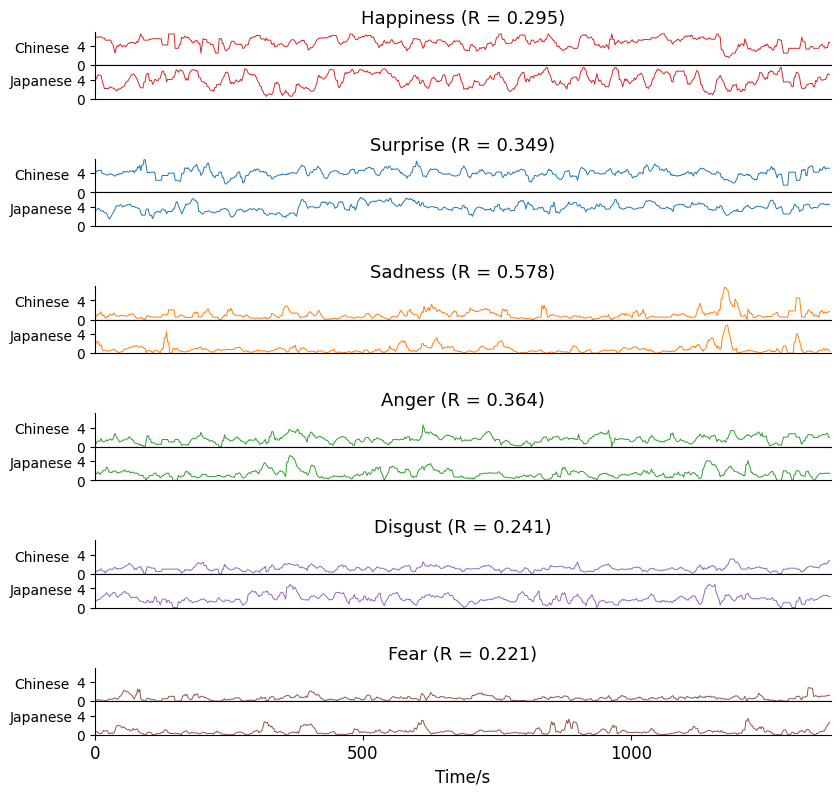

Episode 5 1376


C:\Users\Windows\AppData\Local\Temp\ipykernel_27380\867449811.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


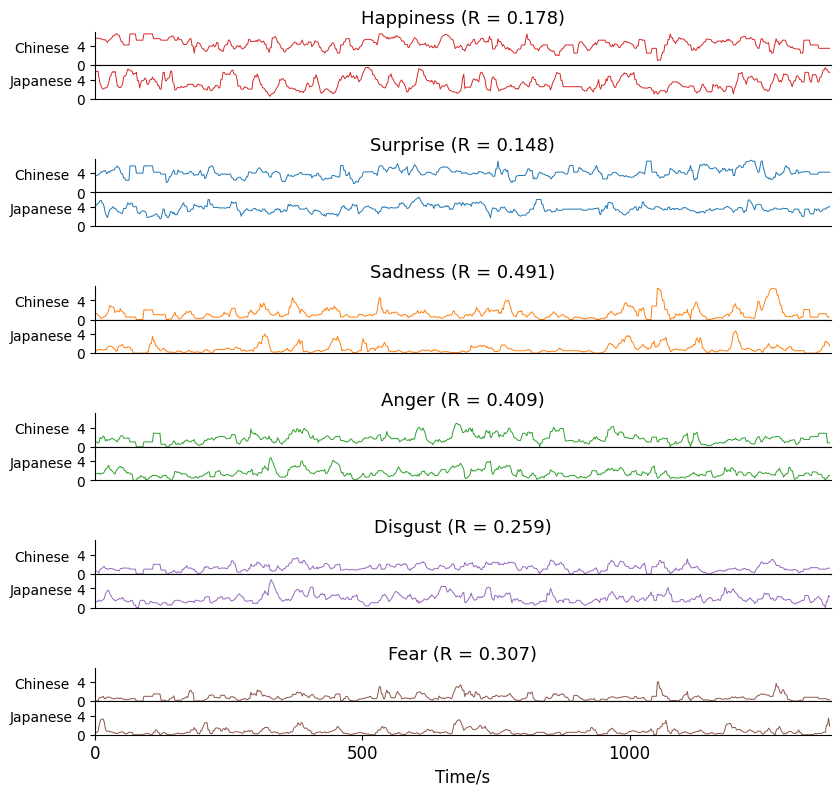

Episode 6 1396


C:\Users\Windows\AppData\Local\Temp\ipykernel_27380\867449811.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


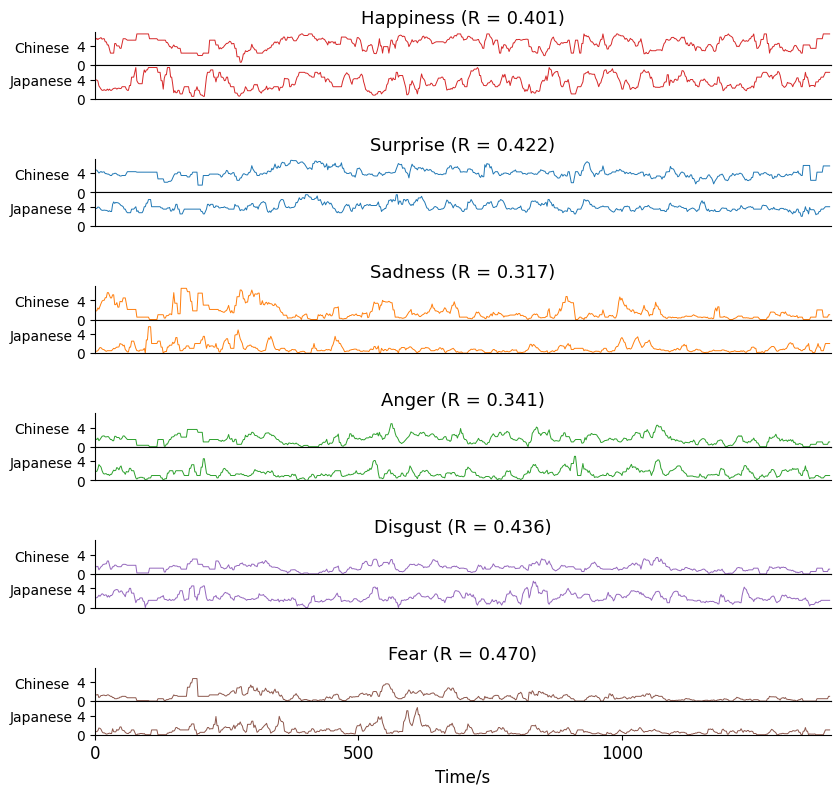

Episode 7 1392


C:\Users\Windows\AppData\Local\Temp\ipykernel_27380\867449811.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


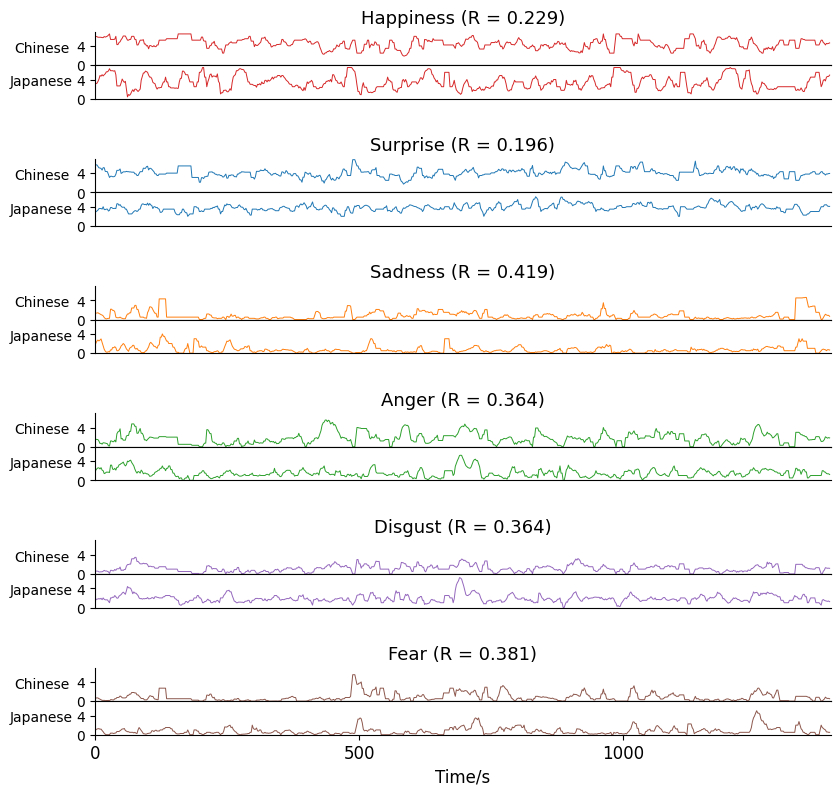

Episode 8 1416


C:\Users\Windows\AppData\Local\Temp\ipykernel_27380\867449811.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


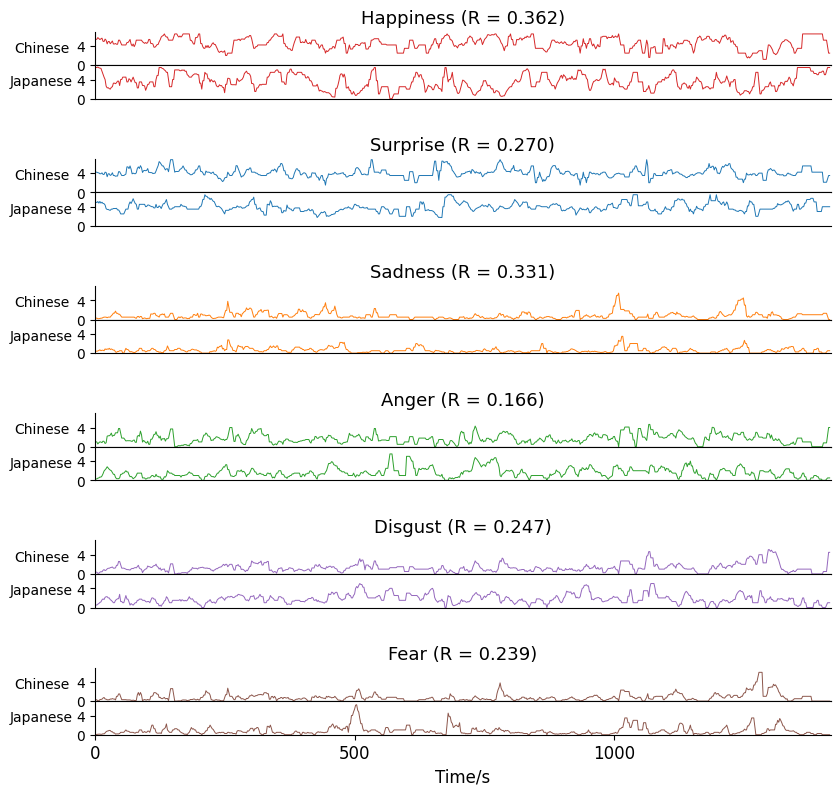

Episode 9 1380


C:\Users\Windows\AppData\Local\Temp\ipykernel_27380\867449811.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


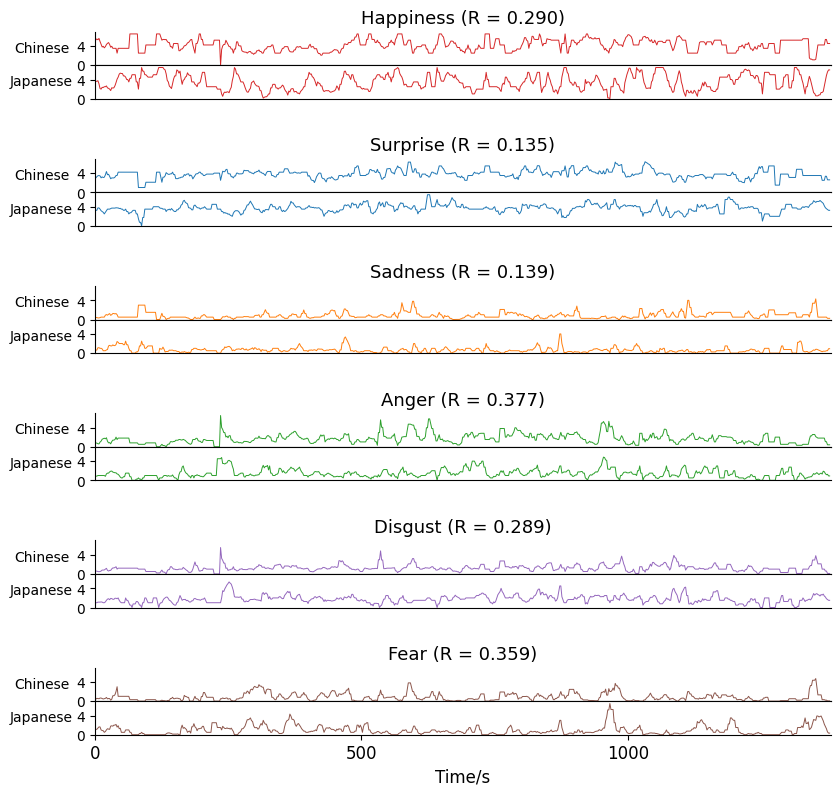

Episode 10 1336


C:\Users\Windows\AppData\Local\Temp\ipykernel_27380\867449811.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


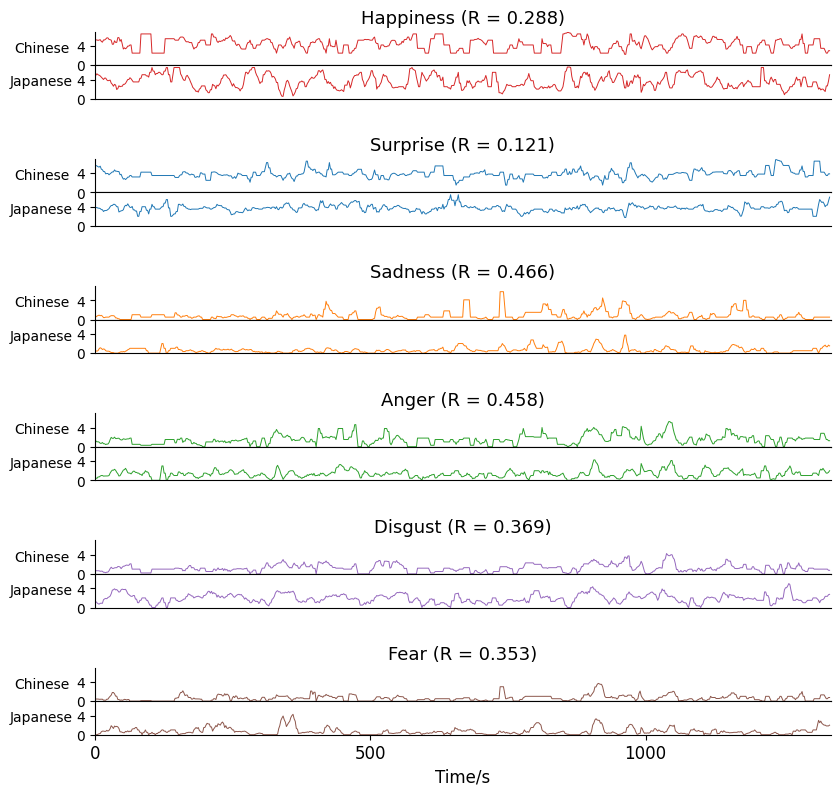

Episode 11 1380


C:\Users\Windows\AppData\Local\Temp\ipykernel_27380\867449811.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


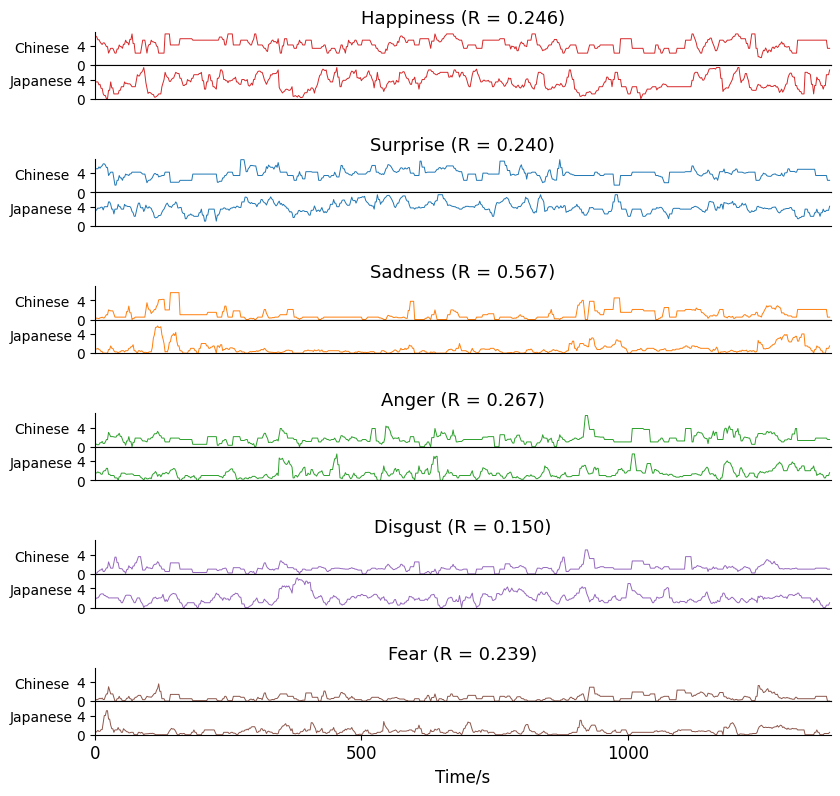

Episode 12 1440


C:\Users\Windows\AppData\Local\Temp\ipykernel_27380\867449811.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


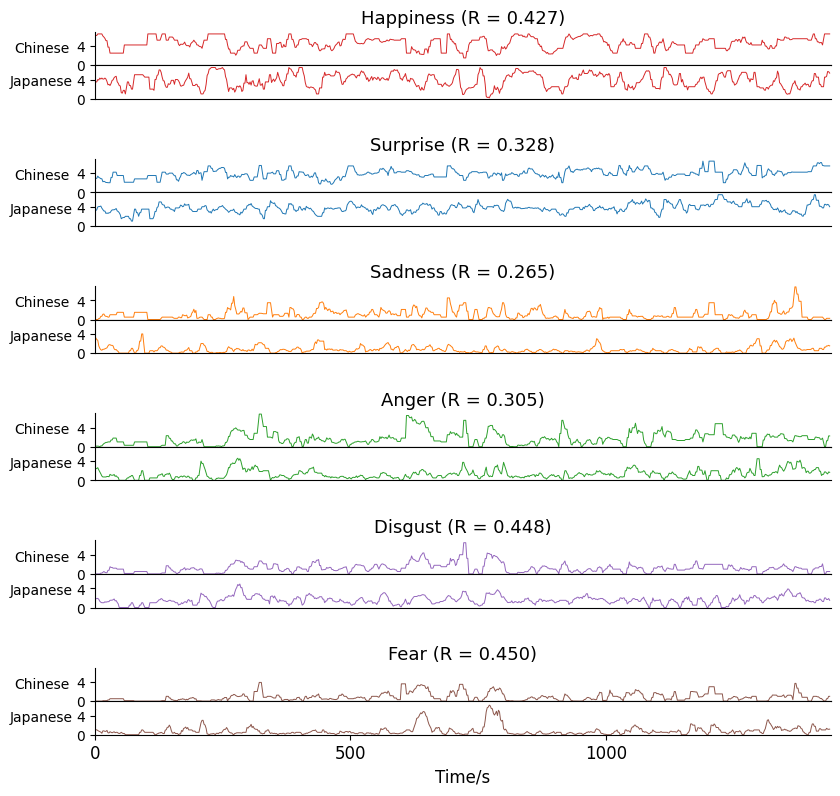

Episode 13 1442


C:\Users\Windows\AppData\Local\Temp\ipykernel_27380\867449811.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


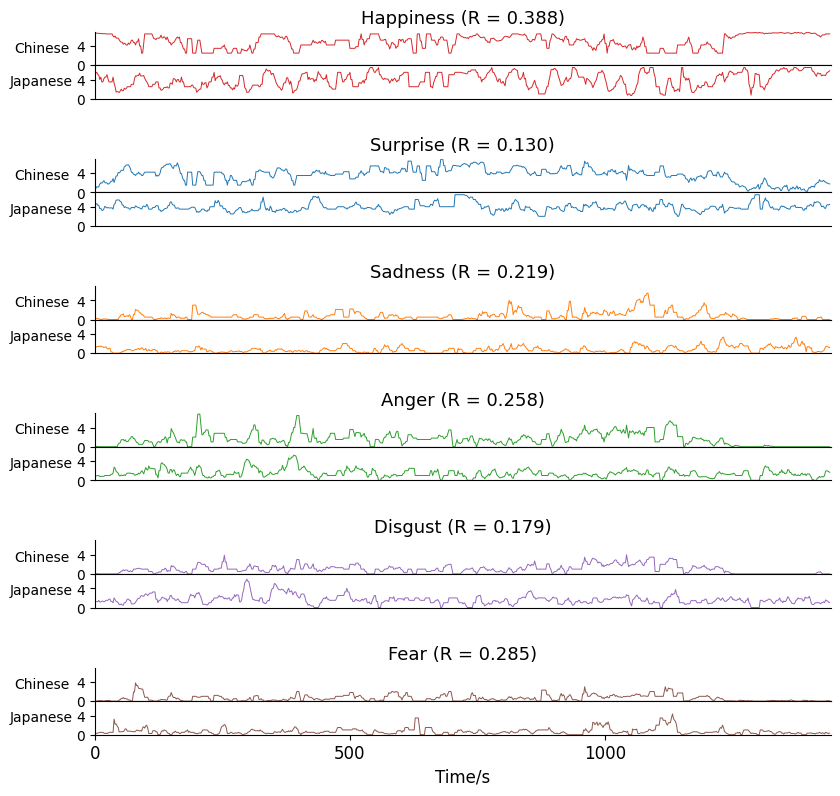

mean
[0.34357254 0.26664715 0.38723081 0.34500711 0.31839429 0.35721661]
Overall


In [5]:
preds_smoothed_chin = np.zeros((0,6))
preds_smoothed_japa = np.zeros((0,6))
rs = np.zeros((13,6))
ps_perm = np.full((13,6), np.nan)
seg_lens = []
for i in range(1,14):
    scores_all, time_points, time_ranges = read_scores('Episode%d.csv' % i)
    preds_smoothed, resample_times = smooth_scores_resample(scores_all, time_points)
    # plot_scores(preds_smoothed, resample_times)

    scores_all2, time_points2, time_ranges2 = read_scores('Uncle_from_Another_World_ep_%d_comment.csv' % i, language='Japanese')
    preds_smoothed2, resample_times2 = smooth_scores_resample(scores_all2, time_points2)
    
    if i in np.arange(1,12):
        cut_range = cut_indices[i][0]
        cut_len = cut_indices[i][1]
        preds_smoothed = np.concatenate((preds_smoothed[:(cut_range[0]-5)//2], preds_smoothed[(cut_range[-1]+5)//2:]), 0)
        resample_times = np.concatenate((resample_times[:(cut_range[0]-5)//2], resample_times[(cut_range[-1]+5)//2:]), 0)
        preds_smoothed2 = np.concatenate((preds_smoothed2[:(cut_range[0]-5)//2], preds_smoothed2[(cut_range[-1]+cut_len+5)//2:]), 0)
        resample_times2 = np.concatenate((resample_times2[:(cut_range[0]-5)//2], resample_times2[(cut_range[-1]+cut_len+5)//2:]), 0)
    
    preds_smoothed2 = preds_smoothed2[:preds_smoothed.shape[0]]
    resample_times2 = resample_times2[:preds_smoothed.shape[0]]
    print('Episode', i, preds_smoothed.shape[0]*2)
    
    preds_smoothed_chin = np.concatenate((preds_smoothed_chin, preds_smoothed), axis=0)
    preds_smoothed_japa = np.concatenate((preds_smoothed_japa, preds_smoothed2), axis=0)

    for k in range(6):
        rs[i-1,k], ps_perm[i-1,k] = time_series_permutation_test(preds_smoothed[:,k], preds_smoothed2[:,k])
        
    plot_scores2(preds_smoothed, preds_smoothed2)
    seg_lens.append(preds_smoothed.shape[0])
seg_lens = np.array(seg_lens)

print('mean')
print(np.mean(rs,axis=0))
print('Overall')
rs_overall = np.zeros(6)
ps_overall_perm = np.full(6, np.nan)
for i in range(6):
    rs_overall[i], ps_overall_perm[i] = time_series_permutation_test(preds_smoothed_chin[:,i], preds_smoothed_japa[:,i])

In [6]:
print(rs_overall)

[0.35055776 0.25365618 0.42526807 0.32635853 0.30752231 0.37148646]


In [7]:
from scipy import stats
for i in range(6):
    result = time_series_permutation_test(preds_smoothed_chin[:,i], preds_smoothed_japa[:,i])
    print(result)

(0.3505577620052111, 0.0002213368747233289)
(0.25365618231097425, 0.0002213368747233289)
(0.425268066479776, 0.00011066843736166445)
(0.32635852939154225, 0.0002213368747233289)
(0.30752230776639466, 0.00011066843736166445)
(0.3714864613177402, 0.0002213368747233289)


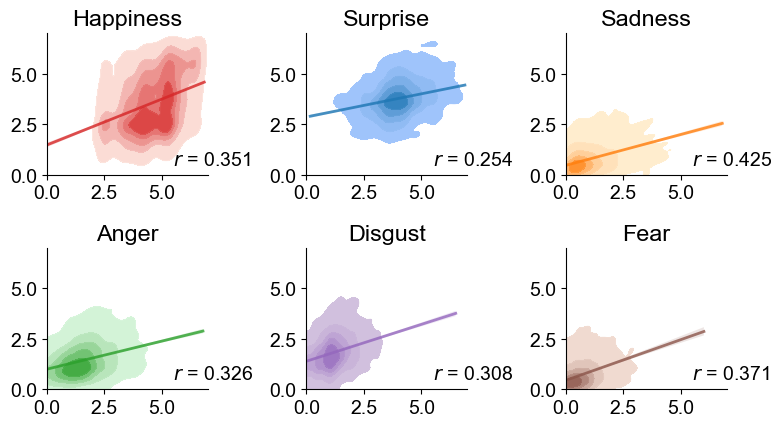

In [8]:
import seaborn as sns
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
import matplotlib
emos = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]
colors = ['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']
gradients = [
    LinearSegmentedColormap.from_list('grad1', ['#FFF0E9', colors[0]]),  # Red
    LinearSegmentedColormap.from_list('grad2', ['#A6C8FF', colors[1]]),  # Blue
    LinearSegmentedColormap.from_list('grad3', ['#FFF1D6', colors[2]]),  # Orange
    LinearSegmentedColormap.from_list('grad4', ['#E0F9E4', colors[3]]),  # Green
    LinearSegmentedColormap.from_list('grad5', ['#D5C6E0', colors[4]]),  # Purple
    LinearSegmentedColormap.from_list('grad6', ['#F5E1D7', colors[5]])   # Brown
]

# orange_cmap = LinearSegmentedColormap.from_list('custom orange',['#FFF0E9', '#F48849'])
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 14
plt.figure(figsize=(8,4.5))
for i in range(6):
    # Concatenate preds_smoothed1 and preds_smoothed2 for each emotion
    data = np.concatenate((np.expand_dims(preds_smoothed_chin[:, i], 1), np.expand_dims(preds_smoothed_japa[:, i], 1)), 1)
    
    # Convert the numpy array to a pandas DataFrame
    df = pd.DataFrame(data, columns=['x', 'y'])  # Give columns names 'x' and 'y'
    
    ax = plt.subplot(2, 3, i + 1)
    
    # First KDE plot with filled contours
    sns.kdeplot(data=df, x='x', y='y', cmap=gradients[i], fill=True, alpha=1.0, levels=6)
    
    # Second KDE plot without filling and with lines
    sns.kdeplot(data=df, x='x', y='y', cmap=gradients[i], fill=False, levels=6, linewidths=0.5, alpha=0.6)
    
    sns.regplot(data=df, x='x', y='y', scatter=False, line_kws={'color': colors[i], 'lw': 2, 'alpha': 0.8})
    
    plt.title(emos[i])
    plt.xticks(np.arange(0,7,2.5))
    plt.yticks(np.arange(0,7,2.5))
    plt.xlim([0,7])
    plt.ylim([0,7])
    plt.xlabel('')
    plt.ylabel('')
    plt.text(5.5,0.5,'$r$ = %.3f' % rs_overall[i])
    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/inter_language_reliability2.svg', bbox_inches='tight', dpi=300)
plt.show()

In [9]:
rs = [0.349,0.256,0.423,0.325,0.306,0.372]
print(np.mean(rs), np.std(rs))

0.3385 0.052309177015128036


Explained variance ratio: [0.45734513 0.22106865 0.15267614 0.09366778 0.04499485 0.03024746]


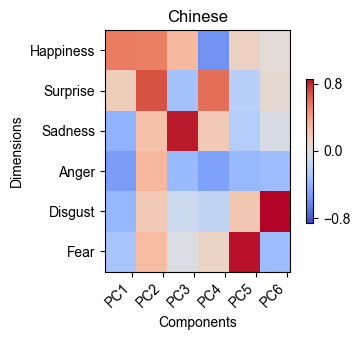

Explained variance ratio: [0.48477905 0.17715231 0.14268622 0.09041177 0.05658062 0.04839003]


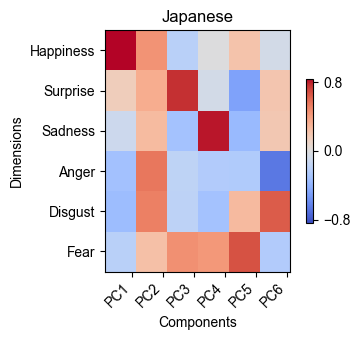

In [10]:
# supplementary figure 19
from sklearn.decomposition import PCA
pca_chin = PCA(n_components=6)
X_pca_chin = pca_chin.fit_transform(preds_smoothed_chin)

pca_japa = PCA(n_components=6)
X_pca_japa = pca_japa.fit_transform(preds_smoothed_japa)

import matplotlib
emos = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]
matplotlib.rcParams['font.size'] = 10
matplotlib.rcParams['font.family'] = 'Arial'
fig, ax = plt.subplots(figsize=(4,3.5))
cax = ax.imshow(pca_chin.components_.transpose(),cmap='coolwarm')
ax.set_aspect(1.3)
plt.xticks(np.arange(0.4,6.4,1),['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6'], rotation=45, ha='right')
plt.yticks(np.arange(6), emos)
plt.xlabel('Components')
plt.ylabel('Dimensions')
cbar = plt.colorbar(cax, shrink=0.6)
cbar.set_ticks([-0.8, 0.0, 0.8])
max_lim = np.maximum(np.nanmax(pca_chin.components_), -np.nanmin(pca_chin.components_))
cax.set_clim([-max_lim, max_lim])
print("Explained variance ratio:", pca_chin.explained_variance_ratio_)
plt.title('Chinese')
plt.tight_layout()
plt.savefig('figures/pca_scores_human_rating_chin.svg', dpi=300)
plt.show()

pca_japa.components_[5,:] = -pca_japa.components_[5,:]
fig, ax = plt.subplots(figsize=(4,3.5))
cax = ax.imshow(pca_japa.components_.transpose(),cmap='coolwarm')
ax.set_aspect(1.3)
plt.xticks(np.arange(0.4,6.4,1),['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6'], rotation=45, ha='right')
plt.yticks(np.arange(6), emos)
plt.xlabel('Components')
plt.ylabel('Dimensions')
cbar = plt.colorbar(cax, shrink=0.6)
cbar.set_ticks([-0.8, 0.0, 0.8])
max_lim = np.maximum(np.nanmax(pca_japa.components_), -np.nanmin(pca_japa.components_))
cax.set_clim([-max_lim, max_lim])
print("Explained variance ratio:", pca_japa.explained_variance_ratio_)
plt.title('Japanese')
plt.tight_layout()
plt.savefig('figures/pca_scores_human_rating_japa.svg', dpi=300)
plt.show()

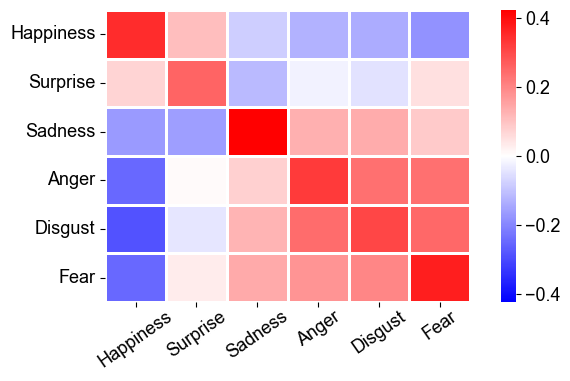

-0.734294843547277 0.734294843547277


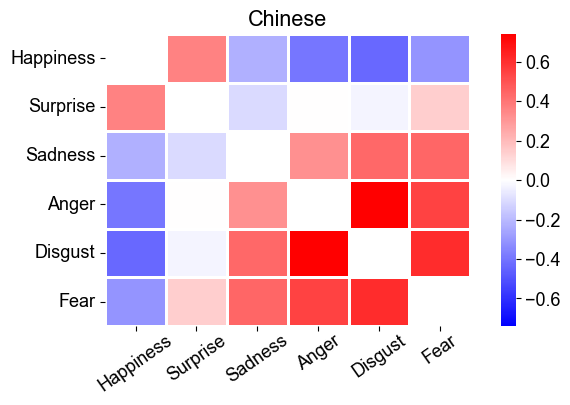

-0.638183916659502 0.638183916659502


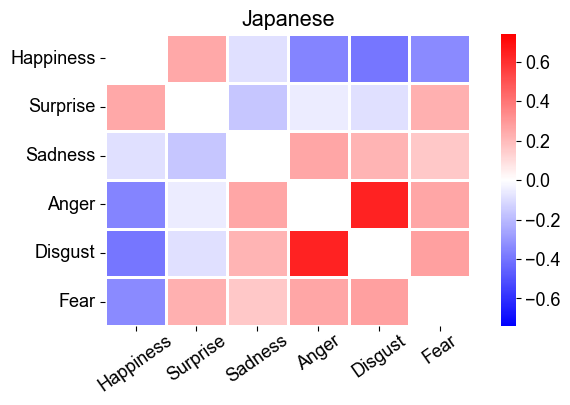

In [12]:
import seaborn as sns
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 13
emos = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]


r_mat = np.zeros((6,6))
p_mat_perm = np.full((6,6), np.nan)
for i in range(6):
    for j in range(6):
        r_mat[i,j], p_mat_perm[i,j] = time_series_permutation_test(preds_smoothed_chin[:,i], preds_smoothed_japa[:,j])

# Assuming r_mat and emos are defined
fig, ax = plt.subplots(figsize=(7, 4))

vmin = -np.max(np.abs(r_mat))  # Minimum value for color scale
vmax = np.max(np.abs(r_mat))   # Maximum value for color scale

# Generate the heatmap, specifying the colormap within the heatmap call
sns.heatmap(r_mat, cmap='bwr', ax=ax, lw = 1, vmin=vmin, vmax=vmax)

# Adjust the aspect ratio
ax.set_aspect(0.8)

# Add colorbar with adjusted ticks
# cbar = plt.colorbar(ax.collections[0], ax=ax, shrink=0.6)
# cbar.set_ticks([-np.max(r_mat), 0.0, np.max(r_mat)])

# Set x and y ticks with rotation for x labels
plt.xticks(np.arange(0.5,6.5,1), emos, rotation=35)
ax.tick_params(axis='x', pad=0.2)
plt.yticks(np.arange(0.5,6.5,1), emos, rotation=0)

# Set color limits (clim) for the heatmap
# ax.set_clim(-np.max(np.abs(r_mat)), np.max(np.abs(r_mat)))

# Adjust the layout and save the figure
plt.tight_layout()
# plt.savefig('figures/r_mat_japa_chin.svg', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

r_mat_chin = np.zeros((6,6))
p_mat_chin_perm = np.full((6,6), np.nan)
for i in range(6):
    for j in range(6):
        r_mat_chin[i,j], p_mat_chin_perm[i,j] = time_series_permutation_test(preds_smoothed_chin[:,i], preds_smoothed_chin[:,j])
    r_mat_chin[i,i] = np.nan
    
# Assuming r_mat and emos are defined
fig, ax = plt.subplots(figsize=(7, 4))

vmin = -np.nanmax(np.abs(r_mat_chin))  # Minimum value for color scale
vmax = np.nanmax(np.abs(r_mat_chin))   # Maximum value for color scale
print(vmin, vmax)
# Generate the heatmap, specifying the colormap within the heatmap call
sns.heatmap(r_mat_chin, cmap='bwr', ax=ax, lw = 1, vmin=-0.74, vmax=0.74)

# Adjust the aspect ratio
ax.set_aspect(0.8)

# Add colorbar with adjusted ticks
# cbar = plt.colorbar(ax.collections[0], ax=ax, shrink=0.6)
# cbar.set_ticks([-np.max(r_mat), 0.0, np.max(r_mat)])

# Set x and y ticks with rotation for x labels
plt.xticks(np.arange(0.5,6.5,1), emos, rotation=35)
ax.tick_params(axis='x', pad=0.2)
plt.yticks(np.arange(0.5,6.5,1), emos, rotation=0)

# Set color limits (clim) for the heatmap
# ax.set_clim(-np.max(np.abs(r_mat)), np.max(np.abs(r_mat)))

# Adjust the layout and save the figure
plt.tight_layout()
plt.savefig('figures/r_mat_chin.svg', dpi=300, bbox_inches='tight')
plt.title('Chinese')
# Show the plot
plt.show()

r_mat_japa = np.zeros((6,6))
p_mat_japa_perm = np.full((6,6), np.nan)
for i in range(6):
    for j in range(6):
        r_mat_japa[i,j], p_mat_japa_perm[i,j] = time_series_permutation_test(preds_smoothed_japa[:,i], preds_smoothed_japa[:,j])
    r_mat_japa[i,i] = np.nan

# Assuming r_mat and emos are defined
fig, ax = plt.subplots(figsize=(7, 4))

vmin = -np.nanmax(np.abs(r_mat_japa))  # Minimum value for color scale
vmax = np.nanmax(np.abs(r_mat_japa))   # Maximum value for color scale
print(vmin, vmax)

# Generate the heatmap, specifying the colormap within the heatmap call
sns.heatmap(r_mat_japa, cmap='bwr', ax=ax, lw = 1, vmin=-0.74, vmax=0.74)

# Adjust the aspect ratio
ax.set_aspect(0.8)

# Add colorbar with adjusted ticks
# cbar = plt.colorbar(ax.collections[0], ax=ax, shrink=0.6)
# cbar.set_ticks([-np.max(r_mat), 0.0, np.max(r_mat)])

# Set x and y ticks with rotation for x labels
plt.xticks(np.arange(0.5,6.5,1), emos, rotation=35)
ax.tick_params(axis='x', pad=0.2)
plt.yticks(np.arange(0.5,6.5,1), emos, rotation=0)

# Set color limits (clim) for the heatmap
# ax.set_clim(-np.max(np.abs(r_mat)), np.max(np.abs(r_mat)))

# Adjust the layout and save the figure
plt.tight_layout()
plt.savefig('figures/r_mat_japa.svg', dpi=300, bbox_inches='tight')
plt.title('Japanese')
# Show the plot
plt.show()

In [13]:
from scipy.stats import pearsonr
pearsonr(r_mat_chin[~np.isnan(r_mat_chin)], r_mat_japa[~np.isnan(r_mat_japa)])

PearsonRResult(statistic=np.float64(0.9477241815548626), pvalue=np.float64(2.021954969012067e-15))

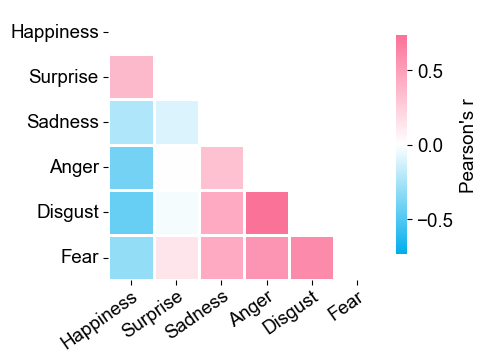

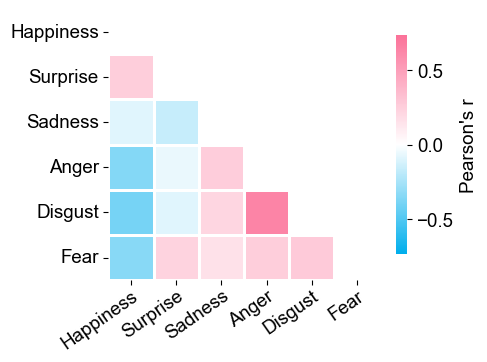

Chinese-Japanese matrix similarity: r = 0.948, p = 8.083e-08
Number of independent emotion pairs: n = 15


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 13.5

emos = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]

# ============================================================
# 1. Compute within-language correlation matrices
# ============================================================

r_mat_chin = np.zeros((6, 6))
r_mat_japa = np.zeros((6, 6))
p_mat_chin_perm = np.full((6, 6), np.nan)
p_mat_japa_perm = np.full((6, 6), np.nan)

for i in range(6):
    for j in range(6):
        r_mat_chin[i, j], p_mat_chin_perm[i, j] = time_series_permutation_test(
            preds_smoothed_chin[:, i],
            preds_smoothed_chin[:, j]
        )

        r_mat_japa[i, j], p_mat_japa_perm[i, j] = time_series_permutation_test(
            preds_smoothed_japa[:, i],
            preds_smoothed_japa[:, j]
        )


# ============================================================
# 2. Bilibili-style diverging colormap
#    negative = blue
#    zero     = white
#    positive = pink
# ============================================================

bilibili_cmap = LinearSegmentedColormap.from_list(
    "bilibili",
    ["#00AEEC", "#FFFFFF", "#FB7299"]
)


# ============================================================
# 3. Only show the lower triangle
# ============================================================

# mask upper triangle + diagonal
mask = np.triu(np.ones_like(r_mat_chin, dtype=bool), k=0)

# Use the same color scale for Chinese and Japanese
lower_idx = np.tril_indices(6, k=-1)

max_abs = max(
    np.max(np.abs(r_mat_chin[lower_idx])),
    np.max(np.abs(r_mat_japa[lower_idx]))
)

# If you want to keep your original fixed range, use:
# max_abs = 0.74


def plot_lower_triangle(r_mat, title, save_path):

    fig, ax = plt.subplots(figsize=(5, 4.8))

    sns.heatmap(
        r_mat,
        mask=mask,
        cmap=bilibili_cmap,
        vmin=-max_abs,
        vmax=max_abs,
        center=0,
        square=True,
        linewidths=1,
        linecolor="white",
        xticklabels=emos,
        yticklabels=emos,
        cbar_kws={
            "shrink": 0.55,
            "label": "Pearson's r"
        },
        ax=ax
    )

    ax.set_title(title, fontsize=15)

    plt.setp(
        ax.get_xticklabels(),
        rotation=35,
        ha="right",
        rotation_mode="anchor"
    )
    plt.setp(
        ax.get_yticklabels(),
        rotation=0
    )

    ax.tick_params(axis='x', pad=1)

    plt.tight_layout()
    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()


# Chinese
plot_lower_triangle(
    r_mat_chin,
    title="",
    save_path="figures/r_mat_chin.svg"
)

# Japanese
plot_lower_triangle(
    r_mat_japa,
    title="",
    save_path="figures/r_mat_japa.svg"
)


# ============================================================
# 4. Compare Chinese vs Japanese
#    ONLY use the lower triangle
# ============================================================

chin_lower = r_mat_chin[lower_idx]
japa_lower = r_mat_japa[lower_idx]

r, p = pearsonr(chin_lower, japa_lower)

print(f"Chinese-Japanese matrix similarity: r = {r:.3f}, p = {p:.3e}")
print(f"Number of independent emotion pairs: n = {len(chin_lower)}")

Episode 1 1406


C:\Users\Windows\AppData\Local\Temp\ipykernel_9880\2062865372.py:107: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


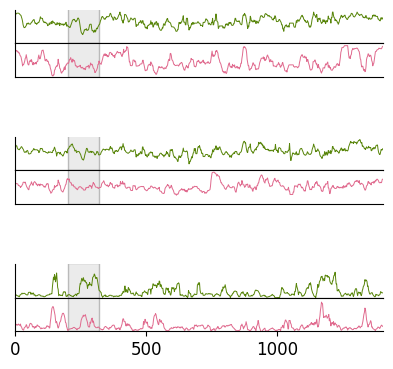

In [8]:

import matplotlib.patches as patches

def highlight_regions(ax, spans, *, alpha=0.25, fc='0.8', ec='0.4',
                      lw=1.0, ls='--', zorder=0):
    """
    在给定 ax 上高亮多个时间区间。
    spans: list[tuple]，每个元素为 (start_sec, end_sec)
    alpha: 透明度，fc: 面色(灰度或颜色)，ec: 边框色
    lw/ls: 边框线宽/线型，zorder: 图层(小一些放到曲线下)
    """
    ymin, ymax = ax.get_ylim()
    for s, e in spans:
        rect = patches.Rectangle((s, ymin), e - s, ymax+0.3 - ymin,
                                 facecolor=fc, edgecolor=ec,
                                 linewidth=lw, linestyle=ls,
                                 alpha=alpha, zorder=zorder)
        ax.add_patch(rect)

preds_smoothed_chin = np.zeros((0,6))
preds_smoothed_japa = np.zeros((0,6))
rs = np.zeros((13,6))
ps_perm = np.full((13,6), np.nan)
seg_lens = []
i=1
scores_all, time_points, time_ranges = read_scores('Episode%d.csv' % i)
preds_smoothed, resample_times = smooth_scores_resample(scores_all, time_points)
# plot_scores(preds_smoothed, resample_times)

scores_all2, time_points2, time_ranges2 = read_scores('Uncle_from_Another_World_ep_%d_comment.csv' % i, language='Japanese')
preds_smoothed2, resample_times2 = smooth_scores_resample(scores_all2, time_points2)

if i in np.arange(1,12):
    cut_range = cut_indices[i][0]
    cut_len = cut_indices[i][1]
    preds_smoothed = np.concatenate((preds_smoothed[:(cut_range[0]-5)//2], preds_smoothed[(cut_range[1]+5)//2:]), 0)
    resample_times = np.concatenate((resample_times[:(cut_range[0]-5)//2], resample_times[(cut_range[1]+5)//2:]), 0)
    preds_smoothed2 = np.concatenate((preds_smoothed2[:(cut_range[0]-5)//2], preds_smoothed2[(cut_range[1]+cut_len+5)//2:]), 0)
    resample_times2 = np.concatenate((resample_times2[:(cut_range[0]-5)//2], resample_times2[(cut_range[1]+cut_len+5)//2:]), 0)

preds_smoothed2 = preds_smoothed2[:preds_smoothed.shape[0]]
resample_times2 = resample_times2[:preds_smoothed.shape[0]]
print('Episode', i, preds_smoothed.shape[0]*2)

preds_smoothed_chin = np.concatenate((preds_smoothed_chin, preds_smoothed), axis=0)
preds_smoothed_japa = np.concatenate((preds_smoothed_japa, preds_smoothed2), axis=0)

for k in range(6):
    rs[i-1,k], ps_perm[i-1,k] = time_series_permutation_test(preds_smoothed[:,k], preds_smoothed2[:,k])
preds_smoothed=preds_smoothed_chin
preds_smoothed2=preds_smoothed_japa
colors = ['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']
emos = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]

vertical_gap_small = 0.001
vertical_gap_large = 0.1
height = 0.056
left1 = 0.05
right1 = 0.97
width = right1 - left1

highlight_spans = [(200, 320)]

language_colors = [
    "#58850A",  # much deeper green
    "#E06A8E",  # much deeper pink
]
fig = plt.figure(figsize=(4, 6))

for j in range(3):
    bottom1 = 1 - (j+1)*height*2 - j*vertical_gap_large
    bottom2 = bottom1 + height
    R, p_perm = time_series_permutation_test(preds_smoothed[:,j], preds_smoothed2[:,j])
    
    ax1 = fig.add_axes([left1, bottom2, width, height])
    ax1.plot(np.arange(preds_smoothed.shape[0])*2, preds_smoothed[:, j], color=language_colors[0], linewidth=0.7)
    ax1.set_ylim([0, 7])
    ax1.set_xlim([0,preds_smoothed.shape[0]*2])
    # ax1.set_title(emos[j]+' (R = %.3f)' % R, fontsize=13)
    ax1.set_yticks([])
    #ax1.set_yticks([0,4], [0,4], fontsize=10)
    ax1.set_xticks([])
    #ax1.set_ylabel('Chinese', fontsize=10, rotation=0, labelpad=25)
    ax1.yaxis.label.set_position((0, 0.3))
    
    ax1.spines['right'].set_visible(False)
    ax1.spines['top'].set_visible(False)
    
    ax2 = fig.add_axes([left1, bottom1, width, height])
    ax2.plot(np.arange(preds_smoothed.shape[0])*2, preds_smoothed2[:, j], color=language_colors[1], linewidth=0.7)
    ax2.set_ylim([0, 7])
    ax2.set_xlim([0,preds_smoothed.shape[0]*2])
    # ax2.set_title(emos[j], fontsize=15)
    #ax2.set_yticks([0,4], [0,4], fontsize=10)
    ax2.set_xticks([])
    ax2.set_yticks([])
    #ax2.set_ylabel('Japanese', fontsize=10, rotation=0, labelpad=25)
    ax2.yaxis.label.set_position((0, 0.3))
    
    ax2.spines['right'].set_visible(False)
    # ax2.spines['top'].set_visible(False)
    highlight_regions(ax1, highlight_spans, alpha=0.5, fc='0.85', ec='0.5', lw=1.0, ls='-', zorder=0)

    highlight_regions(ax2, highlight_spans, alpha=0.5, fc='0.85', ec='0.5', lw=1.0, ls='-', zorder=0)

#ax2.set_xlabel('Time/s', fontsize=12)
ax2.set_xticks(np.arange(0,preds_smoothed.shape[0]*2,500), np.arange(0,preds_smoothed.shape[0]*2,500), fontsize=12)

plt.tight_layout()
plt.savefig('prompt_v4_gpt3_5_turbo_Chin_Japa_lineplot_aligned.svg', dpi=300, bbox_inches='tight')
plt.show()
seg_lens.append(preds_smoothed.shape[0])

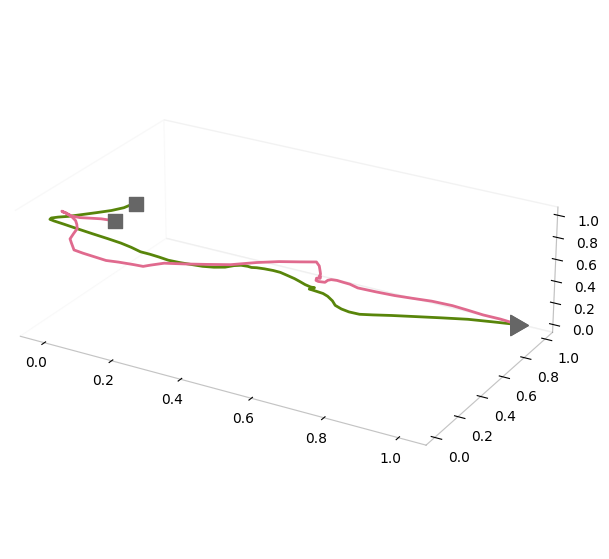

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D  # noqa

def smooth_ma(X, win=None):
    if win is None or win <= 1: return X
    Y = np.empty_like(X, dtype=float)
    T = len(X); half = win // 2
    for t in range(T):
        s = max(0, t-half); e = min(T, t+half+1)
        Y[t] = X[s:e].mean(axis=0)
    return Y

def _center(X, how='t0', win=50):
    if how is None: return X
    if how == 't0':
        return X - X[0]
    elif how == 'mean':
        return X - X.mean(axis=0)
    elif how == 'window':
        w = min(win, len(X))
        return X - X[:w].mean(axis=0)
    elif how == 'min':    return X - X.min(axis=0, keepdims=True)  # 👈 新增
    else:
        raise ValueError("how must be in {'t0','mean','window',None}")

def _normalize(X, method='zscore'):
    """对每个维度做标准化，削弱幅值影响"""
    if method is None: 
        return X
    if method == 'zscore':  # z-score标准化
        std = X.std(axis=0, keepdims=True)
        std[std < 1e-8] = 1.0
        return (X - X.mean(axis=0, keepdims=True)) / std
    elif method == 'minmax':
        minv, maxv = X.min(axis=0, keepdims=True), X.max(axis=0, keepdims=True)
        return (X - minv) / (maxv - minv + 1e-8)
    else:
        raise ValueError("normalize must be None|'zscore'|'minmax'")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_trajs3d(trajs, labels=None, starts=None, ends=None,
                 smooth_win=None, center='t0',
                 normalize='zscore', emos=['dim0','dim1','dim2'],
                 color_by_time=False, linewidth=2.0, colors=None,
                 mark_start_end=True, title=None,
                 # === 新增：按 index 打点 ===
                 special_idx=None,            # int | list[int]，在这些索引处画关键点
                 special_marker='s',          # 关键点形状（默认方块）
                 special_size=60,             # 关键点大小
                 special_color=None,          # 关键点颜色（None 时跟随轨迹色）
                 special_label='Event',
                 leng_show=True,
                 fig_size=(10,6),font_size=14,axis_off=False,
                 box_aspect=[1.2, 1.2, 0.8],save_path=None
                 ):      # legend 名称
    """
    在每条轨迹上指定索引处打点，例如 special_idx=300 或 [100,300,500]
    """

    n = len(trajs)
    if labels is None: labels = [f"traj{i+1}" for i in range(n)]
    if starts is None: starts = [0]*n
    if ends   is None: ends   = [len(trajs[i]) for i in range(n)]
    if colors is None: colors = [None]*n

    fig = plt.figure(figsize=fig_size)
    ax  = fig.add_subplot(111, projection='3d')
    ax.set_box_aspect(box_aspect)  # x:y:z = 1.2:1.2:0.6，压缩z轴

    # --- 去掉背景网格与面板 ---
    ax.grid(False)
    ax.xaxis.pane.set_facecolor((1,1,1,0))
    ax.yaxis.pane.set_facecolor((1,1,1,0))
    ax.zaxis.pane.set_facecolor((1,1,1,0))
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.line.set_color((0,0,0,0.2))
    fig.patch.set_facecolor('white')

    # 留出图例位置
    box = ax.get_position()
    #ax.set_position([box.x0, box.y0, box.width*0.78, box.height])

    line_handles = []
    used_colors  = []
    ax.view_init(elev=25, azim=-60)
    for i, X in enumerate(trajs):
        s, e = starts[i], ends[i]
        seg = smooth_ma(X, win=smooth_win)[s:e]

        seg = _normalize(seg, method=normalize)
        seg = _center(seg, how=center, win=50)

        c = colors[i] if colors[i] is not None else f"C{i}"
        used_colors.append(c)

        # 画主轨迹
        ax.plot(seg[:,0], seg[:,1], seg[:,2], linewidth=linewidth, color=c)
        from matplotlib.path import Path
        import matplotlib.patches as patches
        h = np.sqrt(3)/2
        # ▶ 播放键（等边三角形，向右）
        play_marker = Path([
            (-h/2, -0.5),          # 左下
            (-h/2,  0.5),          # 左上
            ( h/2,  0.0),          # 右尖
            (-h/2, -0.5)
        ], [Path.MOVETO, Path.LINETO, Path.LINETO, Path.CLOSEPOLY])

        # 起止点
        if mark_start_end and len(seg) > 0:
            ax.scatter(seg[0,0], seg[0,1], seg[0,2], s=210, marker=play_marker, zorder=100,color=special_color)
            ax.scatter(seg[-1,0], seg[-1,1], seg[-1,2], s=100, marker='s',zorder=100,color=special_color)
                       #, color=c)

        # 按索引画关键点
        if special_idx is not None:
            if isinstance(special_idx, int):
                idxs = [special_idx]
            else:
                idxs = special_idx
            for idx in idxs:
                if 0 <= idx < len(seg):
                    sc = special_color if special_color else c
                    ax.scatter(seg[idx,0], seg[idx,1], seg[idx,2],
                               s=150, marker='o',
                               color=sc, edgecolors='none')

        line_handles.append(Line2D([0],[0], color=c, lw=linewidth, label=labels[i]))

begin = 100
end = begin + 60

middle=40
choose_emo = np.array([0,1,2])
plot_trajs3d([preds_smoothed[begin:end,choose_emo], preds_smoothed2[begin:end,choose_emo]]
            ,special_idx=None,box_aspect=[5,3,1.5],font_size=16,special_color='#666666',
                center='min',normalize='minmax', smooth_win=50, emos=np.array(emos)[choose_emo].tolist(),
                colors=language_colors, labels=['LLM ratings for Chinese', 'LLM ratings for Japanese'],leng_show=False,
                fig_size=(10,7),
                save_path=f'fig_4_3d_traj_with_events_time_{begin*2}_{end*2}s.svg',
                #title=f"time {begin*2}-{end*2}s",
                )

### LLM – human consistency vs. human – human consistency 

In [1]:
from copy import deepcopy
import pickle
import numpy as np

def align_smooth_scores(preds, time_points, smooth_win=10):
    # cut predicted scores and time_points_german into 8 runs
    cut_index2 = [[0, 22550/25], [22150/25, 32312/25], [36349/25, 48237/25], [47837/25, 57798/25], [58470/25, 70409/25], [70009/25, 85997/25], [89293/25, 97705/25], [97305/25, 117351/25], [120616/25, 123670/25], [123270/25, 141457/25], [145869/25, 149632/25], [149232/25, 152260/25], [154244/25, 178316/25],  [177916/25, 194792/25]]

    time_points_ori = deepcopy(time_points)
    time_points_ori[time_points_ori>=4443] = time_points_ori[time_points_ori>=4443] + (4462-4443)
    time_points_ori[time_points_ori>=4483] = time_points_ori[time_points_ori>=4483] + (4514-4483)
    time_points_ori[time_points_ori>=5177] = time_points_ori[time_points_ori>=5177] + (5210-5177)
    time_points_ori[time_points_ori>=5371] = time_points_ori[time_points_ori>=5371] + (5380-5371)

    # Find time points in the german version. (the frame rate was different from the original movie)
    time_points_german = time_points_ori / (25/(24000/1001))
    
    n_emos = preds.shape[1]
    preds_cut = np.zeros((0,n_emos))
    time_points_german_cut = np.zeros(0)
    for i in range(len(cut_index2)):
        preds_cut = np.concatenate((preds_cut, preds[(time_points_german >= cut_index2[i][0]) & (time_points_german <= cut_index2[i][1]), :]), 0)
        time_points_german_cut = np.concatenate((time_points_german_cut, time_points_german[(time_points_german >= cut_index2[i][0]) & (time_points_german <= cut_index2[i][1])]), 0)

    # Get time of ratings in German version
    time_ratings = []
    seg_lens = [902,882,876,976,924,878,1084,676]
    for i in range(8):
        tmp = np.arange(0,seg_lens[i],2)
        if (i > 0) and (i < 7): # The first and the last runs only have one segment
            tmp = tmp + cut_index2[i*2-1][0]
            tmp[tmp > cut_index2[i*2-1][1]]  = tmp[tmp > cut_index2[i*2-1][1]] + cut_index2[i*2][0] - cut_index2[i*2-1][1] # Add skipped time
        elif i == 7:
            tmp = tmp + cut_index2[i*2-1][0]
        time_ratings.extend(tmp)
        
    # Resample preds_cut to the same sampling rate of ratings_mean (by average over 2s neighboring to time_ratings)
    preds_cut_resample = np.zeros((3599, n_emos))
    for i in range(3599):
        if np.sum((time_points_german_cut < (time_ratings[i]+1)) & (time_points_german_cut >= (time_ratings[i]-1)))==0:
            preds_cut_resample[i,:] = preds_cut_resample[i-1,:]
        else:
            preds_cut_resample[i,:] = np.mean(preds_cut[(time_points_german_cut < (time_ratings[i]+1)) & (time_points_german_cut >= (time_ratings[i]-1)),:], axis=0)

    # Smooth the predicted scores over ts windows
    preds_smoothed = np.zeros(preds_cut_resample.shape)
    for i in range(preds_cut_resample.shape[0]):
        tmp = preds_cut_resample[abs(time_ratings - time_ratings[i]) <= smooth_win//2, :]
        preds_smoothed[i,:] = np.mean(tmp[np.sum(np.abs(tmp), axis=1)!=0, :], axis=0)
    return preds_smoothed, time_ratings


def smooth_scores(preds_cut_resample, time_ratings, smooth_win=10):
    # Smooth the predicted scores over ts windows
    preds_smoothed = np.zeros(preds_cut_resample.shape)
    for i in range(preds_cut_resample.shape[0]):
        tmp = preds_cut_resample[abs(time_ratings - time_ratings[i]) <= smooth_win//2, :]
        preds_smoothed[i,:] = np.mean(tmp, axis=0)
    return preds_smoothed

In [2]:
import h5py
import pickle
import numpy as np
import os
with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Online_human_ratings_danmu\ratings6_sorted_final_12sub.pkl', 'rb') as f:
    human_danmu = pickle.load(f)
    
data_keys = np.arange(0,5756,5)
# data_keys = list(human_danmu.keys())
# time_points_human_danmu = np.zeros(len(data_keys))
human_danmu_mean = np.zeros((len(data_keys), 6))
for i in range(len(data_keys)):
    # time_points_human_danmu[i] = data_keys[i]
    human_danmu_mean[i,:] = np.mean(np.array(human_danmu[data_keys[i]]), axis=1)
    
human_danmu_12 = np.zeros((1152, 6, 12))
for i in range(len(data_keys)):
    # print(data[data_keys[i]])
    for j in range(6):
        for k in range(12):
            human_danmu_12[i,j,k] = human_danmu[data_keys[i]][j][k]
            
path=r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\Lettieri-Forrest\forrest_gump_movie_italian\raw_ratings.mat'
human_movie=np.zeros([12,6,3599])
count = 0
with h5py.File(path,'r') as file:
    for item in file.items():
        # print(item[0])
        tmp = file[item[0]][:][[0,1,3,4,5,2],:] 
        human_movie[count]=tmp
        count += 1
human_movie_mean = np.mean(human_movie, axis=0)
human_movie_mean = human_movie_mean.transpose()

human_movie = human_movie.transpose([2,1,0])
    

with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Emotion_scores\scores_longMovie_gpt3_5_turbo.pkl', 'rb') as f:
    scores_allvideo = pickle.load(f)
llm_danmu = scores_allvideo['forrest_gump']

with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Processed_danmu\danmu_Forrest_Gump_downsample.pkl', 'rb') as f:
    danmu_dict = pickle.load(f)
time_ranges = danmu_dict['forrest_gump.csv_time_range']

time_points_llm_danmu = np.zeros(len(time_ranges))
for i in range(len(time_points_llm_danmu)):
    time_points_llm_danmu[i] = np.mean(time_ranges[i])

time_points_human_danmu = time_points_llm_danmu[np.arange(0,5756,5)]
human_danmu_12_aligned = np.zeros((3599,6,12))
for j in range(12):
    human_danmu_12_aligned[:,:,j], _ = align_smooth_scores(human_danmu_12[:,:,j], time_points_human_danmu)
human_danmu_mean_aligned, _ = align_smooth_scores(human_danmu_mean, time_points_human_danmu)

llm_danmu_aligned, time_ratings = align_smooth_scores(llm_danmu, time_points_llm_danmu)

smooth_win=10
human_movie_aligned = np.zeros(human_movie.shape)
for j in range(12):
    human_movie_aligned[:,:,j] = smooth_scores(human_movie[:,:,j], time_ratings)
    
human_movie_mean_aligned = smooth_scores(human_movie_mean, time_ratings)

In [3]:
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests

def fisher_r_to_z(r):
    return 0.5 * np.log((1 + r) / (1 - r))

In [4]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

cmap = plt.get_cmap('bwr')

red = cmap(0.8)  
blue = cmap(0.4) 

print("Red color code (RGBA):", red)
print("Blue color code (RGBA):", blue)

red_hex = mcolors.rgb2hex(red[:3]) 
blue_hex = mcolors.rgb2hex(blue[:3])

print("Red color code (Hex):", red_hex)
print("Blue color code (Hex):", blue_hex)

Red color code (RGBA): (np.float64(1.0), np.float64(0.4), np.float64(0.4), np.float64(1.0))
Blue color code (RGBA): (np.float64(0.8), np.float64(0.8), np.float64(1.0), np.float64(1.0))
Red color code (Hex): #ff6666
Blue color code (Hex): #ccccff


[3.26131400e-05 3.83262874e-01 4.28788029e-13 3.42989531e-12
 1.02977153e-11 2.04300482e-06]
U-statistic: 669.0, P-value: 0.000160767831723909
U-statistic: 467.0, P-value: 0.32889319622979984
U-statistic: 779.0, P-value: 1.1759536575815864e-07
U-statistic: 770.0, P-value: 2.3091485867754485e-07
U-statistic: 772.0, P-value: 1.9901801706023243e-07
U-statistic: 702.0, P-value: 2.3282932114863114e-05
[1.92921398e-04 3.28893196e-01 4.61829717e-07 4.61829717e-07
 4.61829717e-07 3.49243982e-05]


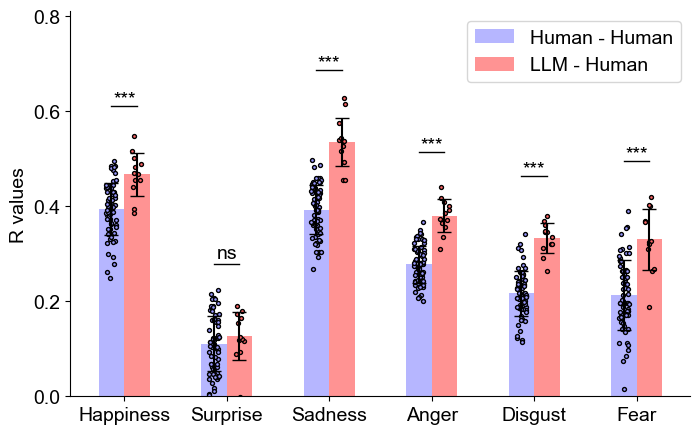

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests

def fisher_r_to_z(r):
    return 0.5 * np.log((1 + r) / (1 - r))
r_llm_human_danmu = np.zeros((6,12))
p_llm_human_danmu_perm = np.full((6,12), np.nan)
for j in range(12):
    for i in range(6):
        r_llm_human_danmu[i,j], p_llm_human_danmu_perm[i,j] = time_series_permutation_test(llm_danmu_aligned[:,i], human_danmu_12_aligned[:,i,j])

r_human_danmu = np.zeros((6,12,12))
p_human_danmu_perm = np.full((6,12,12), np.nan)      
for k in range(12):
    for j in range(k+1,12):
        for i in range(6):
            r_human_danmu[i,k,j], p_human_danmu_perm[i,k,j] = time_series_permutation_test(human_danmu_12_aligned[:,i,k], human_danmu_12_aligned[:,i,j])  
triu_inds = np.triu_indices(12,1)
# print(np.mean(r_llm_human_danmu, axis=1), np.std(r_llm_human_danmu, axis=1))
# for i in range(6):
    # print(np.mean(r_human_danmu[i,:,:][triu_inds]), np.std(r_human_danmu[i,:,:][triu_inds]))
    
ps = np.zeros(6)
for i in range(6):
    group1_z = fisher_r_to_z(r_llm_human_danmu[i,:])
    group2_z = fisher_r_to_z(r_human_danmu[i,:,:][triu_inds])
    t_stat, p_value = ttest_ind(group1_z, group2_z)
    ps[i] = p_value
    # print(t_stat, p_value)

reject, pvals_corrected, _, _ = multipletests(ps, alpha=0.05, method='fdr_bh')
print(pvals_corrected)


from scipy.stats import mannwhitneyu
# Mann-Whitney U 检验
ps = np.zeros(6)
for i in range(6):
    u_stat, p_value = mannwhitneyu(r_llm_human_danmu[i,:], r_human_danmu[i,:,:][triu_inds], alternative='two-sided')
    print(f"U-statistic: {u_stat}, P-value: {p_value}")
    ps[i] = p_value
reject, pvals_corrected, _, _ = multipletests(ps, alpha=0.05, method='fdr_bh')
print(pvals_corrected)


matplotlib.rcParams['font.family'] = 'Arial'
emos = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]
colors = ['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']

bar_width = 0.25
x = np.arange(len(emos))

fig, ax = plt.subplots(figsize=(8, 5))
# ax.bar(x, rs_llm, bar_width, label='LLM', capsize=5, color=[188./255,189./255,50./255])
r_human_danmu_vec = np.zeros((6,66))
for i in range(6):
    r_human_danmu_vec[i] = r_human_danmu[i,:,:][triu_inds]
    
ax.bar(x, np.mean(r_llm_human_danmu, axis=1), bar_width, yerr=np.std(r_llm_human_danmu, axis=1), label='LLM', capsize=5, color='#ff6666', alpha=0.7)
ax.bar(x + bar_width, np.mean(r_human_danmu_vec , axis=1), bar_width, yerr=np.std(r_human_danmu_vec, axis=1), label='Human', capsize=5, color='gray', alpha=0.4)
plt.legend(['LLM - Human','Human - Human'], fontsize=14, loc='upper right',frameon=False)
# 添加散点
for i in range(len(emos)):
    jitter_llm = np.random.uniform(-0.05, 0.05, size=r_llm_human_danmu[i, :].shape)  # 对 LLM-Human 散点添加抖动
    jitter_human = np.random.uniform(-0.05, 0.051, size=r_human_danmu[i, :, :][triu_inds].shape)  # 对 Human-Human 散点添加抖动

    # 对 Human - Human 添加散点
    ax.scatter(
        np.full_like(r_llm_human_danmu[i, :], x[i]) + jitter_llm,  # x 坐标
        r_llm_human_danmu[i, :],  # y 坐标
        color='#ff6666',
        s=8,
        edgecolor='black',  # 设置散点边框颜色
        alpha=0.7  # 设置透明度
    )
    # 对 LLM - Human 添加散点
    ax.scatter(
        np.full_like(r_human_danmu[i, :, :][triu_inds], x[i]+ bar_width ) +jitter_human ,  # x 坐标
        r_human_danmu[i, :, :][triu_inds],  # y 坐标
        color='gray',
        s=8,
        edgecolor='black',  # 设置散点边框颜色
        alpha=0.4  # 设置透明度
    )
    
    p_value = pvals_corrected[i]
    if p_value < 0.001:
        star = "***"
    elif p_value < 0.01:
        star = "**"
    elif p_value < 0.05:
        star = "*"
    else:
        star = 'ns'
    
    y_max = max(np.mean(r_llm_human_danmu[i, :]) + np.std(r_llm_human_danmu[i, :]),
                np.mean(r_human_danmu_vec[i]) + np.std(r_human_danmu_vec[i]))
    y_line = y_max + 0.1  # 横线高度
    # 添加横线
    ax.plot([x[i], x[i] + bar_width], [y_line, y_line], color='black', lw=1)

    # 添加显著性标注
    if p_value >= 0.05:
        ax.text((x[i] + x[i] + bar_width) / 2, y_line+0.005, star, ha='center', va='bottom', fontsize=14, color='black')
    else:
        ax.text((x[i] + x[i] + bar_width) / 2, y_line-0.005, star, ha='center', va='bottom', fontsize=14, color='black')


# 设置 x 轴刻度
ax.set_xticks(x + bar_width/2, emos, fontsize=14)
#ax.set_xticks([])
plt.yticks(np.arange(0,0.81,0.2), fontsize=14)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.ylabel('R values', fontsize=14)
plt.ylim([0, 0.81])
os.makedirs('figures',exist_ok=True)
plt.savefig('figures/r_llm_human_danmu.svg', format = 'svg')
plt.show()

raw p: [0.00048828 0.20361328 0.00048828 0.00048828 0.00048828 0.00048828]
BH-FDR q: [0.00058594 0.20361328 0.00058594 0.00058594 0.00058594 0.00058594]
reject: [ True False  True  True  True  True]
rank-biserial (optional): [1.         0.43589744 1.         1.         1.         1.        ]


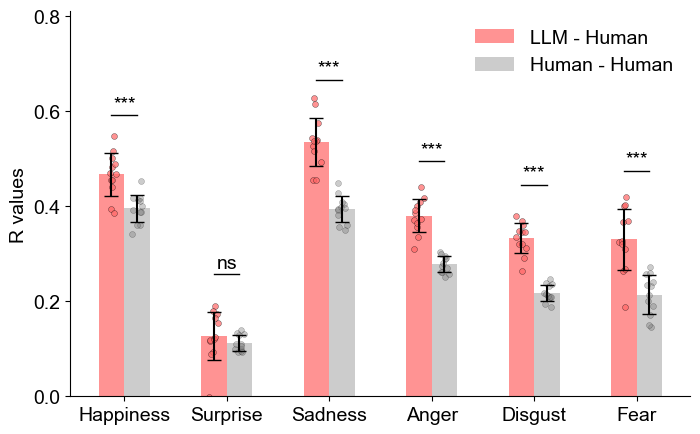

In [6]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from scipy.stats import wilcoxon, ttest_rel
from statsmodels.stats.multitest import multipletests


# -----------------------------
# Utilities
# -----------------------------
def fisher_r_to_z(r, eps=1e-6):
    """
    Fisher r-to-z transform with clipping for numerical stability.
    """
    r = np.asarray(r, dtype=float)
    r = np.clip(r, -1 + eps, 1 - eps)
    return 0.5 * np.log((1 + r) / (1 - r))

def fisher_z_to_r(z):
    z = np.asarray(z, dtype=float)
    return np.tanh(z)

def safe_corrcoef(x, y):
    """Pearson correlation and circular-shift permutation p-value."""
    return time_series_permutation_test(x, y)

def wilcoxon_effect_size_rank_biserial(d):
    """
    Matched-pairs rank-biserial correlation for Wilcoxon signed-rank test.
    d: paired differences (array), zeros will be removed.
    """
    d = np.asarray(d, dtype=float)
    d = d[np.isfinite(d)]
    d = d[d != 0]
    n = len(d)
    if n == 0:
        return np.nan

    abs_d = np.abs(d)
    ranks = np.argsort(np.argsort(abs_d)) + 1  # simple rank (no tie correction)
    # Note: tie correction is typically minor; for exact tie-aware ranks, use scipy.stats.rankdata
    # from scipy.stats import rankdata; ranks = rankdata(abs_d, method="average")

    W_pos = np.sum(ranks[d > 0])
    W_neg = np.sum(ranks[d < 0])
    denom = n * (n + 1) / 2
    return (W_pos - W_neg) / denom


# -----------------------------
# Compute correlations
# -----------------------------
# Shapes assumed:
# llm_danmu_aligned: (T, 6)
# human_danmu_12_aligned: (T, 6, 12)
T = llm_danmu_aligned.shape[0]
assert human_danmu_12_aligned.shape[0] == T
assert human_danmu_12_aligned.shape[1] == 6
assert human_danmu_12_aligned.shape[2] == 12

n_emo = 6
n_rater = 12

# (6, 12): LLM vs each rater
r_llm_human_danmu = np.full((n_emo, n_rater), np.nan)
p_llm_human_danmu_perm = np.full((n_emo, n_rater), np.nan)
for j in range(n_rater):
    for i in range(n_emo):
        r_llm_human_danmu[i, j], p_llm_human_danmu_perm[i, j] = safe_corrcoef(
            llm_danmu_aligned[:, i],
            human_danmu_12_aligned[:, i, j]
        )

# (6, 12, 12): human vs human (upper-tri filled)
r_human_danmu = np.full((n_emo, n_rater, n_rater), np.nan)
p_human_danmu_perm = np.full((n_emo, n_rater, n_rater), np.nan)
for k in range(n_rater):
    for j in range(k + 1, n_rater):
        for i in range(n_emo):
            r_human_danmu[i, k, j], p_human_danmu_perm[i, k, j] = safe_corrcoef(
                human_danmu_12_aligned[:, i, k],
                human_danmu_12_aligned[:, i, j]
            )
            r_human_danmu[i, j, k] = r_human_danmu[i, k, j]  # symmetrize
            p_human_danmu_perm[i, j, k] = p_human_danmu_perm[i, k, j]


# -----------------------------
# Recommended: per-rater mean inter-rater correlation (avoid non-independence)
# For each rater i, compute mean_{j!=i} atanh(r_ij), then tanh back.
# This yields (6, 12) human-human summary aligned with raters -> paired test is valid.
# -----------------------------
r_hh_mean_per_rater = np.full((n_emo, n_rater), np.nan)

for i_emo in range(n_emo):
    for i_rater in range(n_rater):
        # correlations between rater i and all other raters
        others = [j for j in range(n_rater) if j != i_rater]
        r_vec = r_human_danmu[i_emo, i_rater, others]  # length 11
        # Fisher-z average (ignore NaNs)
        z_vec = fisher_r_to_z(r_vec)
        z_mean = np.nanmean(z_vec)
        r_hh_mean_per_rater[i_emo, i_rater] = fisher_z_to_r(z_mean)


# -----------------------------
# Paired statistical test across raters (n=12) for each emotion
# Use Wilcoxon signed-rank on Fisher-z (monotonic -> equivalent ranks, but z is nicer for reporting/averaging).
# -----------------------------
pvals = np.full(n_emo, np.nan)
effect_rb = np.full(n_emo, np.nan)  # optional: rank-biserial effect size

for i in range(n_emo):
    z1 = fisher_r_to_z(r_llm_human_danmu[i, :])
    z2 = fisher_r_to_z(r_hh_mean_per_rater[i, :])

    mask = np.isfinite(z1) & np.isfinite(z2)
    z1m, z2m = z1[mask], z2[mask]

    # Wilcoxon signed-rank (two-sided)
    # If you prefer parametric: ttest_rel(z1m, z2m)
    if len(z1m) < 3:
        pvals[i] = np.nan
        effect_rb[i] = np.nan
        continue

    stat, p = wilcoxon(z1m, z2m, alternative="two-sided", zero_method="wilcox")
    pvals[i] = p

    d = (z1m - z2m)
    effect_rb[i] = wilcoxon_effect_size_rank_biserial(d)

# BH-FDR across 6 emotion dimensions
reject, qvals, _, _ = multipletests(pvals, alpha=0.05, method="fdr_bh")
print("raw p:", pvals)
print("BH-FDR q:", qvals)
print("reject:", reject)
print("rank-biserial (optional):", effect_rb)


# -----------------------------
# Plot (now both groups have 12 points; human-human is per-rater mean)
# -----------------------------
np.random.seed(0)  # for jitter reproducibility

matplotlib.rcParams["font.family"] = "Arial"
emos = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]

bar_width = 0.25
x = np.arange(len(emos))

fig, ax = plt.subplots(figsize=(8, 5))

# Bars: mean ± std across raters (n=12)
mean_llm = np.nanmean(r_llm_human_danmu, axis=1)
std_llm = np.nanstd(r_llm_human_danmu, axis=1)

mean_hh = np.nanmean(r_hh_mean_per_rater, axis=1)
std_hh = np.nanstd(r_hh_mean_per_rater, axis=1)

ax.bar(
    x, mean_llm, bar_width, yerr=std_llm,
    label="LLM - Human", capsize=5, color="#ff6666", alpha=0.7
)
ax.bar(
    x + bar_width, mean_hh, bar_width, yerr=std_hh,
    label="Human - Human", capsize=5, color="gray", alpha=0.4
)

plt.legend(fontsize=14, loc="upper right", frameon=False)

# Scatter points (12 points each group, paired by rater)
for i in range(len(emos)):
    y1 = r_llm_human_danmu[i, :]
    y2 = r_hh_mean_per_rater[i, :]

    jitter1 = np.random.uniform(-0.05, 0.05, size=y1.shape)
    jitter2 = np.random.uniform(-0.05, 0.05, size=y2.shape)

    ax.scatter(
        np.full_like(y1, x[i]) + jitter1,
        y1,
        color="#ff6666", s=18, edgecolor="black", alpha=0.7, linewidth=0.3
    )
    ax.scatter(
        np.full_like(y2, x[i] + bar_width) + jitter2,
        y2,
        color="gray", s=18, edgecolor="black", alpha=0.4, linewidth=0.3
    )

    # (Optional) connect paired points to show pairing
    # for rr in range(n_rater):
    #     if np.isfinite(y1[rr]) and np.isfinite(y2[rr]):
    #         ax.plot([x[i], x[i] + bar_width], [y1[rr], y2[rr]], color="black", alpha=0.1, lw=0.5)

    # Significance stars based on FDR q-values
    q = qvals[i]
    if np.isnan(q):
        star = "na"
    elif q < 0.001:
        star = "***"
    elif q < 0.01:
        star = "**"
    elif q < 0.05:
        star = "*"
    else:
        star = "ns"

    y_max = np.nanmax([mean_llm[i] + std_llm[i], mean_hh[i] + std_hh[i]])
    y_line = y_max + 0.08
    ax.plot([x[i], x[i] + bar_width], [y_line, y_line], color="black", lw=1)
    ax.text((x[i] + x[i] + bar_width) / 2, y_line + 0.005, star,
            ha="center", va="bottom", fontsize=14, color="black")

ax.set_xticks(x + bar_width / 2, emos, fontsize=14)
plt.yticks(np.arange(0, 0.81, 0.2), fontsize=14)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

plt.ylabel("R values", fontsize=14)
plt.ylim([0, 0.81])

os.makedirs("figures", exist_ok=True)
plt.savefig("figures/r_llm_human_danmu_new.svg", format="svg")
plt.show()


### Cross-model consistency

In [17]:
from copy import deepcopy

with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Emotion_scores\scores_longMovie_gpt3_5_turbo.pkl', 'rb') as f:
    scores_allvideo = pickle.load(f)
print(scores_allvideo.keys())
preds = scores_allvideo['forrest_gump']

with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Processed_danmu\danmu_Forrest_Gump_downsample.pkl', 'rb') as f:
    danmu_dict = pickle.load(f)
time_ranges = danmu_dict['forrest_gump.csv_time_range']


dict_keys(['error_count_list', 'forrest_gump'])


In [18]:
# with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Emotion_scores\scores_longMovie_kimi.pkl', 'rb') as f:
#     scores_allvideo = pickle.load(f)
# print(scores_allvideo.keys())
# preds = scores_allvideo['forrest_gump']

# with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Emotion_scores\scores_longMovie_gpt4o.pkl', 'rb') as f:
#     scores_allvideo = pickle.load(f)
# scores_allvideo['forrest_gump'] = deepcopy(scores_allvideo['阿甘正传'])
# del scores_allvideo['阿甘正传']
# print(scores_allvideo.keys())
# print(scores_allvideo['forrest_gump'].shape)
# with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Emotion_scores\scores_longMovie_gpt4o.pkl', 'wb') as f:
#     pickle.dump(scores_allvideo, f)

# with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Emotion_scores\scores_longMovie_deepseek.pkl', 'rb') as f:
data = np.load(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Emotion_scores\scores_longMovie_deepseek.npy')
scores_allvideo = {}
scores_allvideo['forrest_gump'] = data
with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Emotion_scores\scores_longMovie_deepseek.pkl', 'wb') as f:
    pickle.dump(scores_allvideo, f)

with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Emotion_scores\scores_longMovie_firstHalf_gpt3_5_turbo.pkl', 'rb') as f:
    scores_allvideo = pickle.load(f)
print(scores_allvideo['scores_allvideo'].keys())
print(scores_allvideo['scores_allvideo']['阿甘正传-firstHalf'].shape)
scores_allvideo['forrest_gump'] = deepcopy(scores_allvideo['scores_allvideo']['阿甘正传-firstHalf'])
with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Emotion_scores\scores_longMovie_firstHalf_gpt3_5_turbo.pkl', 'wb') as f:
    pickle.dump(scores_allvideo, f)

with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Emotion_scores\scores_longMovie_secondHalf_gpt3_5_turbo.pkl', 'rb') as f:
    scores_allvideo = pickle.load(f)
print(scores_allvideo['scores_allvideo'].keys())
print(scores_allvideo['scores_allvideo']['阿甘正传-secondHalf'].shape)
scores_allvideo['forrest_gump'] = deepcopy(scores_allvideo['scores_allvideo']['阿甘正传-secondHalf'])
with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Emotion_scores\scores_longMovie_secondHalf_gpt3_5_turbo.pkl', 'wb') as f:
    pickle.dump(scores_allvideo, f)

dict_keys(['阿甘正传-firstHalf'])
(3514, 6)
dict_keys(['阿甘正传-secondHalf'])
(3697, 6)


In [19]:
# cut predicted scores and time_points_german into 8 runs
cut_index2 = [[0, 22550/25], [22150/25, 32312/25], [36349/25, 48237/25], [47837/25, 57798/25], [58470/25, 70409/25], [70009/25, 85997/25], [89293/25, 97705/25], [97305/25, 117351/25], [120616/25, 123670/25], [123270/25, 141457/25], [145869/25, 149632/25], [149232/25, 152260/25], [154244/25, 178316/25],  [177916/25, 194792/25]]
time_points = np.zeros(len(time_ranges))
for i in range(len(time_points)):
    time_points[i] = np.mean(time_ranges[i])
# Find time points in the original movie (time points are for bilibili version, which cut 4 segments)

time_points_ori = deepcopy(time_points)
time_points_ori[time_points_ori>=4443] = time_points_ori[time_points_ori>=4443] + (4462-4443)
time_points_ori[time_points_ori>=4483] = time_points_ori[time_points_ori>=4483] + (4514-4483)
time_points_ori[time_points_ori>=5177] = time_points_ori[time_points_ori>=5177] + (5210-5177)
time_points_ori[time_points_ori>=5371] = time_points_ori[time_points_ori>=5371] + (5380-5371)

# Find time points in the german version. (the frame rate was different from the original movie)
time_points_german = time_points_ori / (25/(24000/1001))

preds_cut = np.zeros((0,6))
time_points_german_cut = np.zeros(0)
for i in range(len(cut_index2)):
    preds_cut = np.concatenate((preds_cut, preds[(time_points_german >= cut_index2[i][0]) & (time_points_german <= cut_index2[i][1]), :]), 0)
    time_points_german_cut = np.concatenate((time_points_german_cut, time_points_german[(time_points_german >= cut_index2[i][0]) & (time_points_german <= cut_index2[i][1])]), 0)

# Get time of ratings in German version
time_ratings = []
seg_lens = [902,882,876,976,924,878,1084,676]
for i in range(8):
    tmp = np.arange(0,seg_lens[i],2)
    if (i > 0) and (i < 7): # The first and the last runs only have one segment
        tmp = tmp + cut_index2[i*2-1][0]
        tmp[tmp > cut_index2[i*2-1][1]]  = tmp[tmp > cut_index2[i*2-1][1]] + cut_index2[i*2][0] - cut_index2[i*2-1][1] # Add skipped time
    elif i == 7:
        tmp = tmp + cut_index2[i*2-1][0]
    time_ratings.extend(tmp)
    
# Resample preds_cut to the same sampling rate of ratings_mean (by average over 2s neighboring to time_ratings)
preds_cut_resample = np.zeros((3599, 6))
for i in range(3599):
    if np.sum((time_points_german_cut < (time_ratings[i]+1)) & (time_points_german_cut >= (time_ratings[i]-1)))==0:
        preds_cut_resample[i,:] = preds_cut_resample[i-1,:]
    else:
        preds_cut_resample[i,:] = np.mean(preds_cut[(time_points_german_cut < (time_ratings[i]+1)) & (time_points_german_cut >= (time_ratings[i]-1)),:], axis=0)

# Smooth the predicted scores over 10s windows
preds_smoothed1 = np.zeros(preds_cut_resample.shape)
for i in range(preds_cut_resample.shape[0]):
    tmp = preds_cut_resample[abs(time_ratings - time_ratings[i]) <= 5, :]
    preds_smoothed1[i,:] = np.mean(tmp[np.sum(np.abs(tmp), axis=1)!=0, :], axis=0)
    
    

with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Emotion_scores\scores_longMovie_kimi.pkl', 'rb') as f:
    scores_allvideo = pickle.load(f)
print(scores_allvideo.keys())
preds = scores_allvideo['forrest_gump']

with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Processed_danmu\danmu_Forrest_Gump_downsample.pkl', 'rb') as f:
    danmu_dict = pickle.load(f)
time_ranges = danmu_dict['forrest_gump.csv_time_range']

# cut predicted scores and time_points_german into 8 runs
cut_index2 = [[0, 22550/25], [22150/25, 32312/25], [36349/25, 48237/25], [47837/25, 57798/25], [58470/25, 70409/25], [70009/25, 85997/25], [89293/25, 97705/25], [97305/25, 117351/25], [120616/25, 123670/25], [123270/25, 141457/25], [145869/25, 149632/25], [149232/25, 152260/25], [154244/25, 178316/25],  [177916/25, 194792/25]]
time_points = np.zeros(len(time_ranges))
for i in range(len(time_points)):
    time_points[i] = np.mean(time_ranges[i])
# Find time points in the original movie (time points are for bilibili version, which cut 4 segments)

time_points_ori = deepcopy(time_points)
time_points_ori[time_points_ori>=4443] = time_points_ori[time_points_ori>=4443] + (4462-4443)
time_points_ori[time_points_ori>=4483] = time_points_ori[time_points_ori>=4483] + (4514-4483)
time_points_ori[time_points_ori>=5177] = time_points_ori[time_points_ori>=5177] + (5210-5177)
time_points_ori[time_points_ori>=5371] = time_points_ori[time_points_ori>=5371] + (5380-5371)

# Find time points in the german version. (the frame rate was different from the original movie)
time_points_german = time_points_ori / (25/(24000/1001))

preds_cut = np.zeros((0,6))
time_points_german_cut = np.zeros(0)
for i in range(len(cut_index2)):
    preds_cut = np.concatenate((preds_cut, preds[(time_points_german >= cut_index2[i][0]) & (time_points_german <= cut_index2[i][1]), :]), 0)
    time_points_german_cut = np.concatenate((time_points_german_cut, time_points_german[(time_points_german >= cut_index2[i][0]) & (time_points_german <= cut_index2[i][1])]), 0)

# Get time of ratings in German version
time_ratings = []
seg_lens = [902,882,876,976,924,878,1084,676]
for i in range(8):
    tmp = np.arange(0,seg_lens[i],2)
    if (i > 0) and (i < 7): # The first and the last runs only have one segment
        tmp = tmp + cut_index2[i*2-1][0]
        tmp[tmp > cut_index2[i*2-1][1]]  = tmp[tmp > cut_index2[i*2-1][1]] + cut_index2[i*2][0] - cut_index2[i*2-1][1] # Add skipped time
    elif i == 7:
        tmp = tmp + cut_index2[i*2-1][0]
    time_ratings.extend(tmp)
    
# Resample preds_cut to the same sampling rate of ratings_mean (by average over 2s neighboring to time_ratings)
preds_cut_resample = np.zeros((3599, 6))
for i in range(3599):
    if np.sum((time_points_german_cut < (time_ratings[i]+1)) & (time_points_german_cut >= (time_ratings[i]-1)))==0:
        preds_cut_resample[i,:] = preds_cut_resample[i-1,:]
    else:
        preds_cut_resample[i,:] = np.mean(preds_cut[(time_points_german_cut < (time_ratings[i]+1)) & (time_points_german_cut >= (time_ratings[i]-1)),:], axis=0)

# Smooth the predicted scores over 10s windows
preds_smoothed2 = np.zeros(preds_cut_resample.shape)
for i in range(preds_cut_resample.shape[0]):
    tmp = preds_cut_resample[abs(time_ratings - time_ratings[i]) <= 5, :]
    preds_smoothed2[i,:] = np.mean(tmp[np.sum(np.abs(tmp), axis=1)!=0, :], axis=0)
    
rs = np.zeros(6)
ps_perm = np.full(6, np.nan)
for i in range(6):
    rs[i], ps_perm[i] = time_series_permutation_test(preds_smoothed1[:,i], preds_smoothed2[:,i])
    

dict_keys(['error_count_list', 'forrest_gump'])


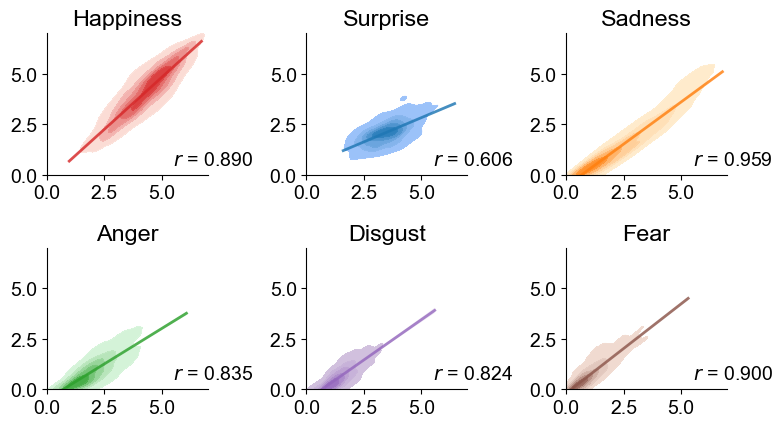

In [24]:
import seaborn as sns
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
emos = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]
colors = ['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']
gradients = [
    LinearSegmentedColormap.from_list('grad1', ['#FFF0E9', colors[0]]),  # Red
    LinearSegmentedColormap.from_list('grad2', ['#A6C8FF', colors[1]]),  # Blue
    LinearSegmentedColormap.from_list('grad3', ['#FFF1D6', colors[2]]),  # Orange
    LinearSegmentedColormap.from_list('grad4', ['#E0F9E4', colors[3]]),  # Green
    LinearSegmentedColormap.from_list('grad5', ['#D5C6E0', colors[4]]),  # Purple
    LinearSegmentedColormap.from_list('grad6', ['#F5E1D7', colors[5]])   # Brown
]

# orange_cmap = LinearSegmentedColormap.from_list('custom orange',['#FFF0E9', '#F48849'])
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 14
plt.figure(figsize=(8,4.5))
for i in range(6):
    # Concatenate preds_smoothed1 and preds_smoothed2 for each emotion
    data = np.concatenate((np.expand_dims(preds_smoothed1[:, i], 1), np.expand_dims(preds_smoothed2[:, i], 1)), 1)
    
    # Convert the numpy array to a pandas DataFrame
    df = pd.DataFrame(data, columns=['x', 'y'])  # Give columns names 'x' and 'y'
    
    ax = plt.subplot(2, 3, i + 1)
    
    # First KDE plot with filled contours
    sns.kdeplot(data=df, x='x', y='y', cmap=gradients[i], fill=True, alpha=1.0, levels=6)
    
    # Second KDE plot without filling and with lines
    sns.kdeplot(data=df, x='x', y='y', cmap=gradients[i], fill=False, levels=6, linewidths=0.5, alpha=0.6)
    
    sns.regplot(data=df, x='x', y='y', scatter=False, line_kws={'color': colors[i], 'lw': 2, 'alpha': 0.8})
    
    plt.title(emos[i])
    plt.xticks(np.arange(0,7,2.5))
    plt.yticks(np.arange(0,7,2.5))
    plt.xlim([0,7])
    plt.ylim([0,7])
    plt.xlabel('')
    plt.ylabel('')
    plt.text(5.5,0.5,'$r$ = %.3f' % rs[i])
    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/inter_model_reliability2.svg', bbox_inches='tight', dpi=300)
plt.show()

In [25]:
# Cross-model consistency (supplementary)

preds_smoothed_gpt3_5 = preds_smoothed1
preds_smoothed_kimi = preds_smoothed2

with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Emotion_scores\scores_longMovie_gpt4o.pkl', 'rb') as f:
    scores_allvideo = pickle.load(f)
print(scores_allvideo.keys())
preds = scores_allvideo['forrest_gump']

with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Processed_danmu\danmu_Forrest_Gump_downsample.pkl', 'rb') as f:
    danmu_dict = pickle.load(f)
time_ranges = danmu_dict['forrest_gump.csv_time_range']

# cut predicted scores and time_points_german into 8 runs
cut_index2 = [[0, 22550/25], [22150/25, 32312/25], [36349/25, 48237/25], [47837/25, 57798/25], [58470/25, 70409/25], [70009/25, 85997/25], [89293/25, 97705/25], [97305/25, 117351/25], [120616/25, 123670/25], [123270/25, 141457/25], [145869/25, 149632/25], [149232/25, 152260/25], [154244/25, 178316/25],  [177916/25, 194792/25]]
time_points = np.zeros(len(time_ranges))
for i in range(len(time_points)):
    time_points[i] = np.mean(time_ranges[i])
# Find time points in the original movie (time points are for bilibili version, which cut 4 segments)

time_points_ori = deepcopy(time_points)
time_points_ori[time_points_ori>=4443] = time_points_ori[time_points_ori>=4443] + (4462-4443)
time_points_ori[time_points_ori>=4483] = time_points_ori[time_points_ori>=4483] + (4514-4483)
time_points_ori[time_points_ori>=5177] = time_points_ori[time_points_ori>=5177] + (5210-5177)
time_points_ori[time_points_ori>=5371] = time_points_ori[time_points_ori>=5371] + (5380-5371)

# Find time points in the german version. (the frame rate was different from the original movie)
time_points_german = time_points_ori / (25/(24000/1001))

preds_cut = np.zeros((0,6))
time_points_german_cut = np.zeros(0)
for i in range(len(cut_index2)):
    preds_cut = np.concatenate((preds_cut, preds[(time_points_german >= cut_index2[i][0]) & (time_points_german <= cut_index2[i][1]), :]), 0)
    time_points_german_cut = np.concatenate((time_points_german_cut, time_points_german[(time_points_german >= cut_index2[i][0]) & (time_points_german <= cut_index2[i][1])]), 0)

# Get time of ratings in German version
time_ratings = []
seg_lens = [902,882,876,976,924,878,1084,676]
for i in range(8):
    tmp = np.arange(0,seg_lens[i],2)
    if (i > 0) and (i < 7): # The first and the last runs only have one segment
        tmp = tmp + cut_index2[i*2-1][0]
        tmp[tmp > cut_index2[i*2-1][1]]  = tmp[tmp > cut_index2[i*2-1][1]] + cut_index2[i*2][0] - cut_index2[i*2-1][1] # Add skipped time
    elif i == 7:
        tmp = tmp + cut_index2[i*2-1][0]
    time_ratings.extend(tmp)
    
# Resample preds_cut to the same sampling rate of ratings_mean (by average over 2s neighboring to time_ratings)
preds_cut_resample = np.zeros((3599, 6))
for i in range(3599):
    if np.sum((time_points_german_cut < (time_ratings[i]+1)) & (time_points_german_cut >= (time_ratings[i]-1)))==0:
        preds_cut_resample[i,:] = preds_cut_resample[i-1,:]
    else:
        preds_cut_resample[i,:] = np.mean(preds_cut[(time_points_german_cut < (time_ratings[i]+1)) & (time_points_german_cut >= (time_ratings[i]-1)),:], axis=0)

# Smooth the predicted scores over 10s windows
preds_smoothed_gpt4o = np.zeros(preds_cut_resample.shape)
for i in range(preds_cut_resample.shape[0]):
    tmp = preds_cut_resample[abs(time_ratings - time_ratings[i]) <= 5, :]
    preds_smoothed_gpt4o[i,:] = np.mean(tmp[np.sum(np.abs(tmp), axis=1)!=0, :], axis=0)
    
    
with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Emotion_scores\scores_longMovie_deepseek.pkl', 'rb') as f:
    scores_allvideo = pickle.load(f)
print(scores_allvideo.keys())

preds = scores_allvideo['forrest_gump']
# cut predicted scores and time_points_german into 8 runs
cut_index2 = [[0, 22550/25], [22150/25, 32312/25], [36349/25, 48237/25], [47837/25, 57798/25], [58470/25, 70409/25], [70009/25, 85997/25], [89293/25, 97705/25], [97305/25, 117351/25], [120616/25, 123670/25], [123270/25, 141457/25], [145869/25, 149632/25], [149232/25, 152260/25], [154244/25, 178316/25],  [177916/25, 194792/25]]
time_points = np.zeros(len(time_ranges))
for i in range(len(time_points)):
    time_points[i] = np.mean(time_ranges[i])
# Find time points in the original movie (time points are for bilibili version, which cut 4 segments)

time_points_ori = deepcopy(time_points)
time_points_ori[time_points_ori>=4443] = time_points_ori[time_points_ori>=4443] + (4462-4443)
time_points_ori[time_points_ori>=4483] = time_points_ori[time_points_ori>=4483] + (4514-4483)
time_points_ori[time_points_ori>=5177] = time_points_ori[time_points_ori>=5177] + (5210-5177)
time_points_ori[time_points_ori>=5371] = time_points_ori[time_points_ori>=5371] + (5380-5371)

# Find time points in the german version. (the frame rate was different from the original movie)
time_points_german = time_points_ori / (25/(24000/1001))

preds_cut = np.zeros((0,6))
time_points_german_cut = np.zeros(0)
for i in range(len(cut_index2)):
    preds_cut = np.concatenate((preds_cut, preds[(time_points_german >= cut_index2[i][0]) & (time_points_german <= cut_index2[i][1]), :]), 0)
    time_points_german_cut = np.concatenate((time_points_german_cut, time_points_german[(time_points_german >= cut_index2[i][0]) & (time_points_german <= cut_index2[i][1])]), 0)

# Get time of ratings in German version
time_ratings = []
seg_lens = [902,882,876,976,924,878,1084,676]
for i in range(8):
    tmp = np.arange(0,seg_lens[i],2)
    if (i > 0) and (i < 7): # The first and the last runs only have one segment
        tmp = tmp + cut_index2[i*2-1][0]
        tmp[tmp > cut_index2[i*2-1][1]]  = tmp[tmp > cut_index2[i*2-1][1]] + cut_index2[i*2][0] - cut_index2[i*2-1][1] # Add skipped time
    elif i == 7:
        tmp = tmp + cut_index2[i*2-1][0]
    time_ratings.extend(tmp)
    
# Resample preds_cut to the same sampling rate of ratings_mean (by average over 2s neighboring to time_ratings)
preds_cut_resample = np.zeros((3599, 6))
for i in range(3599):
    if np.sum((time_points_german_cut < (time_ratings[i]+1)) & (time_points_german_cut >= (time_ratings[i]-1)))==0:
        preds_cut_resample[i,:] = preds_cut_resample[i-1,:]
    else:
        preds_cut_resample[i,:] = np.mean(preds_cut[(time_points_german_cut < (time_ratings[i]+1)) & (time_points_german_cut >= (time_ratings[i]-1)),:], axis=0)

# Smooth the predicted scores over 10s windows
preds_smoothed_deepseek = np.zeros(preds_cut_resample.shape)
for i in range(preds_cut_resample.shape[0]):
    tmp = preds_cut_resample[abs(time_ratings - time_ratings[i]) <= 5, :]
    preds_smoothed_deepseek[i,:] = np.mean(tmp[np.sum(np.abs(tmp), axis=1)!=0, :], axis=0)

dict_keys(['forrest_gump'])
dict_keys(['forrest_gump'])


In [26]:
preds_smoothed_all = {}
preds_smoothed_all['gpt3_5'] = preds_smoothed_gpt3_5
preds_smoothed_all['kimi'] = preds_smoothed_kimi
preds_smoothed_all['gpt4o'] = preds_smoothed_gpt4o
preds_smoothed_all['deepseek'] = preds_smoothed_deepseek
keys = list(preds_smoothed_all.keys())

In [35]:
rs_cross_model = np.zeros((4,4,6))
ps_cross_model_perm = np.full((4,4,6), np.nan)
for i in range(4):
    for j in range(i+1,4):
        for k in range(6):
            rs_cross_model[i,j,k], ps_cross_model_perm[i,j,k] = time_series_permutation_test(preds_smoothed_all[keys[i]][:,k], preds_smoothed_all[keys[j]][:,k])
        print(keys[i], keys[j], rs_cross_model[i,j,:])
        print(np.mean(rs_cross_model[i,j,:]), np.std(rs_cross_model[i,j,:]))

gpt3_5 kimi [0.89002856 0.60579647 0.95875703 0.834947   0.82447736 0.89972482]
0.8356218743831288 0.11193443974480026
gpt3_5 gpt4o [0.84160607 0.63534909 0.95570351 0.81903558 0.83320479 0.88188223]
0.827796878204453 0.0971409488849258
gpt3_5 deepseek [0.82997555 0.62275746 0.95526778 0.79507912 0.75900439 0.85155167]
0.8022726629955527 0.1006255240536412
kimi gpt4o [0.9452175  0.80564231 0.95349937 0.90286638 0.88573872 0.92899649]
0.9036601277207913 0.0496356660673355
kimi deepseek [0.93601923 0.74835145 0.95639821 0.89901824 0.83102384 0.91148123]
0.8803820324004515 0.07077750485919578
gpt4o deepseek [0.94123921 0.88463336 0.96853074 0.92460403 0.88529916 0.92968001]
0.9223310862309031 0.02984286799587042


In [ ]:
def fisher_r_to_z(r):
    return 0.5 * np.log((1 + r) / (1 - r))

def fisher_z_to_r(z):
    return np.tanh(z)

for i in range(4):
    for j in range(i+1,4):
        print(keys[i], keys[j], fisher_z_to_r(np.mean(fisher_r_to_z(rs_cross_model[i,j,:]))))

gpt3_5 kimi 0.0
gpt3_5 gpt4o 0.0
gpt3_5 deepseek 0.0
kimi gpt4o 0.0
kimi deepseek 0.0
gpt4o deepseek 0.0


gpt3_5 kimi [0.89002856 0.60579647 0.95875703 0.834947   0.82447736 0.89972482]


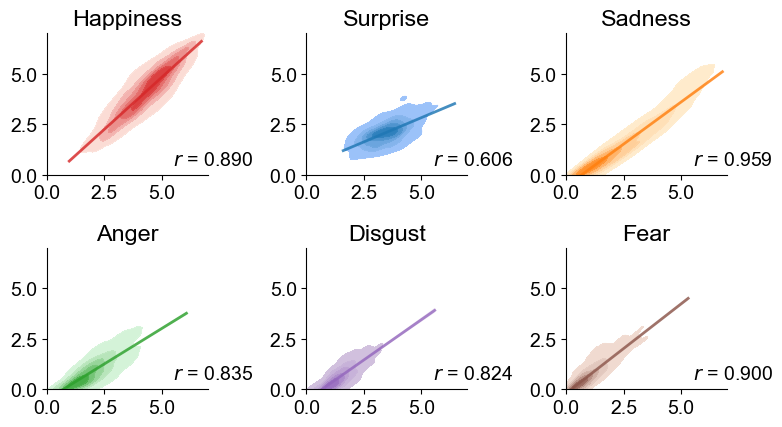

gpt3_5 gpt4o [0.84160607 0.63534909 0.95570351 0.81903558 0.83320479 0.88188223]


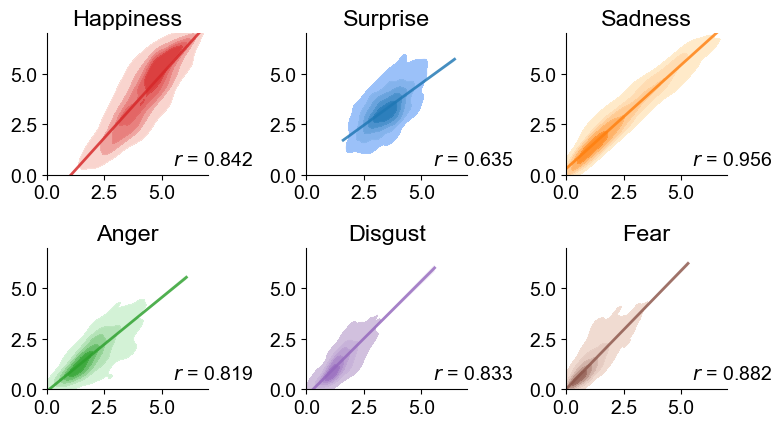

gpt3_5 deepseek [0.82997555 0.62275746 0.95526778 0.79507912 0.75900439 0.85155167]


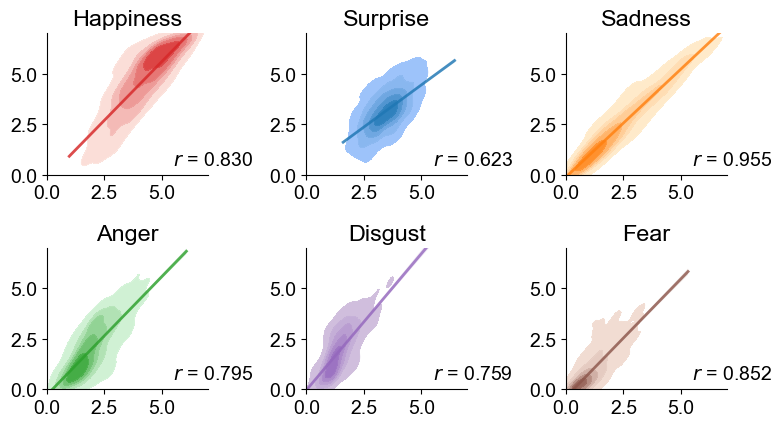

kimi gpt4o [0.9452175  0.80564231 0.95349937 0.90286638 0.88573872 0.92899649]


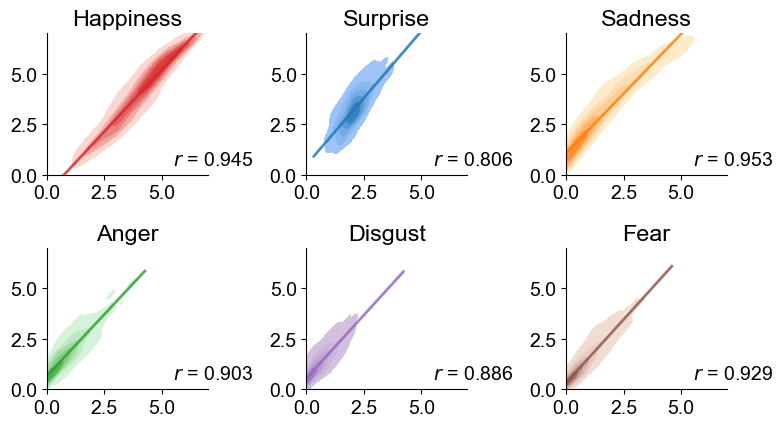

kimi deepseek [0.93601923 0.74835145 0.95639821 0.89901824 0.83102384 0.91148123]


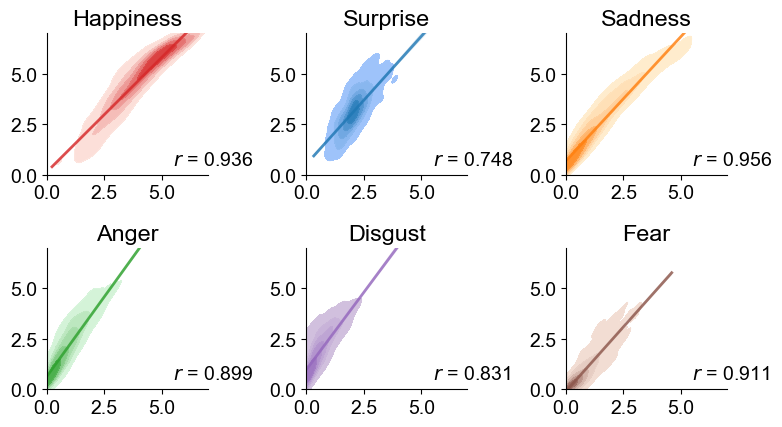

gpt4o deepseek [0.94123921 0.88463336 0.96853074 0.92460403 0.88529916 0.92968001]


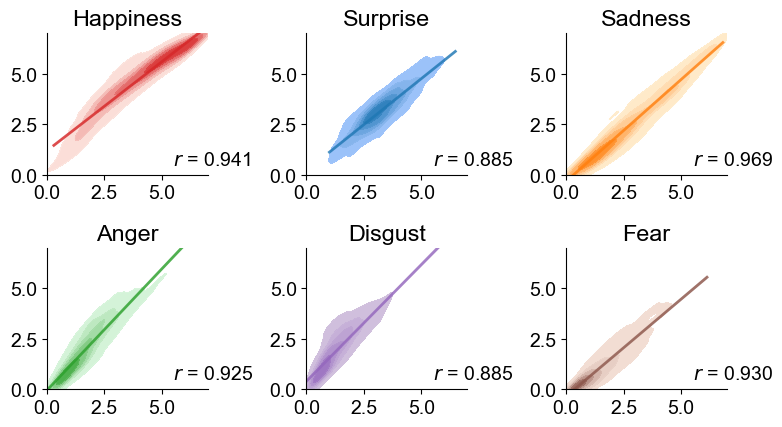

In [33]:
ps_cross_model_perm = np.full((4,4,6), np.nan)
for i in range(4):
    for j in range(i+1,4):
        for k in range(6):
            rs_cross_model[i,j,k], ps_cross_model_perm[i,j,k] = time_series_permutation_test(preds_smoothed_all[keys[i]][:,k], preds_smoothed_all[keys[j]][:,k])
        print(keys[i], keys[j], rs_cross_model[i,j,:])       
        
        plt.figure(figsize=(8,4.5))
        for k in range(6):
            # Concatenate preds_smoothed1 and preds_smoothed2 for each emotion
            data = np.concatenate((np.expand_dims(preds_smoothed_all[keys[i]][:,k], 1), np.expand_dims(preds_smoothed_all[keys[j]][:,k], 1)), 1)
            
            # Convert the numpy array to a pandas DataFrame
            df = pd.DataFrame(data, columns=['x', 'y'])  # Give columns names 'x' and 'y'
            
            ax = plt.subplot(2, 3, k + 1)
            
            # First KDE plot with filled contours
            sns.kdeplot(data=df, x='x', y='y', cmap=gradients[k], fill=True, alpha=1.0, levels=6)
            
            # Second KDE plot without filling and with lines
            sns.kdeplot(data=df, x='x', y='y', cmap=gradients[k], fill=False, levels=6, linewidths=0.5, alpha=0.6)
            
            sns.regplot(data=df, x='x', y='y', scatter=False, line_kws={'color': colors[k], 'lw': 2, 'alpha': 0.8})
            
            plt.title(emos[k])
            plt.xticks(np.arange(0,7,2.5))
            plt.yticks(np.arange(0,7,2.5))
            plt.xlim([0,7])
            plt.ylim([0,7])
            plt.xlabel('')
            plt.ylabel('')
            plt.text(5.5,0.5,'$r$ = %.3f' % rs_cross_model[i,j,k])
            
            ax.spines['right'].set_visible(False)
            ax.spines['top'].set_visible(False)

        plt.tight_layout()
        plt.savefig('figures/r_%s_%s_kde.svg' % (keys[i], keys[j]), dpi=300)
        plt.show()

### Cross-time consistency

In [29]:
from copy import deepcopy
with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Emotion_scores\scores_longMovie_firstHalf_gpt3_5_turbo.pkl', 'rb') as f:
    scores_allvideo = pickle.load(f)
print(scores_allvideo.keys())
preds = scores_allvideo['forrest_gump']

with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Processed_danmu\danmu_Forrest_Gump_downsample_firstHalf.pkl', 'rb') as f:
    danmu_dict = pickle.load(f)
time_ranges = danmu_dict['阿甘正传-firstHalf.csv_time_range']

# cut predicted scores and time_points_german into 8 runs
cut_index2 = [[0, 22550/25], [22150/25, 32312/25], [36349/25, 48237/25], [47837/25, 57798/25], [58470/25, 70409/25], [70009/25, 85997/25], [89293/25, 97705/25], [97305/25, 117351/25], [120616/25, 123670/25], [123270/25, 141457/25], [145869/25, 149632/25], [149232/25, 152260/25], [154244/25, 178316/25],  [177916/25, 194792/25]]
time_points = np.zeros(len(time_ranges))
for i in range(len(time_points)):
    time_points[i] = np.mean(time_ranges[i])
# Find time points in the original movie (time points are for bilibili version, which cut 4 segments)

time_points_ori = deepcopy(time_points)
time_points_ori[time_points_ori>=4443] = time_points_ori[time_points_ori>=4443] + (4462-4443)
time_points_ori[time_points_ori>=4483] = time_points_ori[time_points_ori>=4483] + (4514-4483)
time_points_ori[time_points_ori>=5177] = time_points_ori[time_points_ori>=5177] + (5210-5177)
time_points_ori[time_points_ori>=5371] = time_points_ori[time_points_ori>=5371] + (5380-5371)

# Find time points in the german version. (the frame rate was different from the original movie)
time_points_german = time_points_ori / (25/(24000/1001))

preds_cut = np.zeros((0,6))
time_points_german_cut = np.zeros(0)
for i in range(len(cut_index2)):
    preds_cut = np.concatenate((preds_cut, preds[(time_points_german >= cut_index2[i][0]) & (time_points_german <= cut_index2[i][1]), :]), 0)
    time_points_german_cut = np.concatenate((time_points_german_cut, time_points_german[(time_points_german >= cut_index2[i][0]) & (time_points_german <= cut_index2[i][1])]), 0)

# Get time of ratings in German version
time_ratings = []
seg_lens = [902,882,876,976,924,878,1084,676]
for i in range(8):
    tmp = np.arange(0,seg_lens[i],2)
    if (i > 0) and (i < 7): # The first and the last runs only have one segment
        tmp = tmp + cut_index2[i*2-1][0]
        tmp[tmp > cut_index2[i*2-1][1]]  = tmp[tmp > cut_index2[i*2-1][1]] + cut_index2[i*2][0] - cut_index2[i*2-1][1] # Add skipped time
    elif i == 7:
        tmp = tmp + cut_index2[i*2-1][0]
    time_ratings.extend(tmp)
    
# Resample preds_cut to the same sampling rate of ratings_mean (by average over 2s neighboring to time_ratings)
preds_cut_resample = np.zeros((3599, 6))
for i in range(3599):
    if np.sum((time_points_german_cut < (time_ratings[i]+1)) & (time_points_german_cut >= (time_ratings[i]-1)))==0:
        preds_cut_resample[i,:] = preds_cut_resample[i-1,:]
    else:
        preds_cut_resample[i,:] = np.mean(preds_cut[(time_points_german_cut < (time_ratings[i]+1)) & (time_points_german_cut >= (time_ratings[i]-1)),:], axis=0)

# Smooth the predicted scores over 10s windows
preds_smoothed1 = np.zeros(preds_cut_resample.shape)
for i in range(preds_cut_resample.shape[0]):
    tmp = preds_cut_resample[abs(time_ratings - time_ratings[i]) <= 5, :]
    preds_smoothed1[i,:] = np.mean(tmp[np.sum(np.abs(tmp), axis=1)!=0, :], axis=0)
    
    

with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Emotion_scores\scores_longMovie_secondHalf_gpt3_5_turbo.pkl', 'rb') as f:
    scores_allvideo = pickle.load(f)
print(scores_allvideo.keys())
preds = scores_allvideo['forrest_gump']

with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Processed_danmu\danmu_Forrest_Gump_downsample_secondHalf.pkl', 'rb') as f:
    danmu_dict = pickle.load(f)
time_ranges = danmu_dict['阿甘正传-secondHalf.csv_time_range']

# cut predicted scores and time_points_german into 8 runs
cut_index2 = [[0, 22550/25], [22150/25, 32312/25], [36349/25, 48237/25], [47837/25, 57798/25], [58470/25, 70409/25], [70009/25, 85997/25], [89293/25, 97705/25], [97305/25, 117351/25], [120616/25, 123670/25], [123270/25, 141457/25], [145869/25, 149632/25], [149232/25, 152260/25], [154244/25, 178316/25],  [177916/25, 194792/25]]
time_points = np.zeros(len(time_ranges))
for i in range(len(time_points)):
    time_points[i] = np.mean(time_ranges[i])
# Find time points in the original movie (time points are for bilibili version, which cut 4 segments)

time_points_ori = deepcopy(time_points)
time_points_ori[time_points_ori>=4443] = time_points_ori[time_points_ori>=4443] + (4462-4443)
time_points_ori[time_points_ori>=4483] = time_points_ori[time_points_ori>=4483] + (4514-4483)
time_points_ori[time_points_ori>=5177] = time_points_ori[time_points_ori>=5177] + (5210-5177)
time_points_ori[time_points_ori>=5371] = time_points_ori[time_points_ori>=5371] + (5380-5371)

# Find time points in the german version. (the frame rate was different from the original movie)
time_points_german = time_points_ori / (25/(24000/1001))

preds_cut = np.zeros((0,6))
time_points_german_cut = np.zeros(0)
for i in range(len(cut_index2)):
    preds_cut = np.concatenate((preds_cut, preds[(time_points_german >= cut_index2[i][0]) & (time_points_german <= cut_index2[i][1]), :]), 0)
    time_points_german_cut = np.concatenate((time_points_german_cut, time_points_german[(time_points_german >= cut_index2[i][0]) & (time_points_german <= cut_index2[i][1])]), 0)

# Get time of ratings in German version
time_ratings = []
seg_lens = [902,882,876,976,924,878,1084,676]
for i in range(8):
    tmp = np.arange(0,seg_lens[i],2)
    if (i > 0) and (i < 7): # The first and the last runs only have one segment
        tmp = tmp + cut_index2[i*2-1][0]
        tmp[tmp > cut_index2[i*2-1][1]]  = tmp[tmp > cut_index2[i*2-1][1]] + cut_index2[i*2][0] - cut_index2[i*2-1][1] # Add skipped time
    elif i == 7:
        tmp = tmp + cut_index2[i*2-1][0]
    time_ratings.extend(tmp)
    
# Resample preds_cut to the same sampling rate of ratings_mean (by average over 2s neighboring to time_ratings)
preds_cut_resample = np.zeros((3599, 6))
for i in range(3599):
    if np.sum((time_points_german_cut < (time_ratings[i]+1)) & (time_points_german_cut >= (time_ratings[i]-1)))==0:
        preds_cut_resample[i,:] = preds_cut_resample[i-1,:]
    else:
        preds_cut_resample[i,:] = np.mean(preds_cut[(time_points_german_cut < (time_ratings[i]+1)) & (time_points_german_cut >= (time_ratings[i]-1)),:], axis=0)

# Smooth the predicted scores over 10s windows
preds_smoothed2 = np.zeros(preds_cut_resample.shape)
for i in range(preds_cut_resample.shape[0]):
    tmp = preds_cut_resample[abs(time_ratings - time_ratings[i]) <= 5, :]
    preds_smoothed2[i,:] = np.mean(tmp[np.sum(np.abs(tmp), axis=1)!=0, :], axis=0)
    
rs = np.zeros(6)
ps_perm = np.full(6, np.nan)
for i in range(6):
    rs[i], ps_perm[i] = time_series_permutation_test(preds_smoothed1[:,i], preds_smoothed2[:,i])
    

dict_keys(['scores_allvideo', 'error_count_list', 'forrest_gump'])
dict_keys(['scores_allvideo', 'error_count_list', 'forrest_gump'])


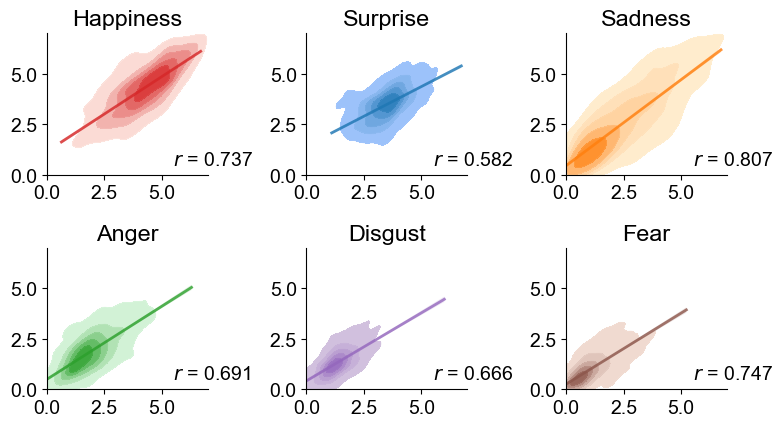

In [30]:
emos = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]
import seaborn as sns
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
colors = ['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']
gradients = [
    LinearSegmentedColormap.from_list('grad1', ['#FFF0E9', colors[0]]),  # Red
    LinearSegmentedColormap.from_list('grad2', ['#A6C8FF', colors[1]]),  # Blue
    LinearSegmentedColormap.from_list('grad3', ['#FFF1D6', colors[2]]),  # Orange
    LinearSegmentedColormap.from_list('grad4', ['#E0F9E4', colors[3]]),  # Green
    LinearSegmentedColormap.from_list('grad5', ['#D5C6E0', colors[4]]),  # Purple
    LinearSegmentedColormap.from_list('grad6', ['#F5E1D7', colors[5]])   # Brown
]

# orange_cmap = LinearSegmentedColormap.from_list('custom orange',['#FFF0E9', '#F48849'])
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 14
plt.figure(figsize=(8,4.5))
for i in range(6):
    # Concatenate preds_smoothed1 and preds_smoothed2 for each emotion
    data = np.concatenate((np.expand_dims(preds_smoothed1[:, i], 1), np.expand_dims(preds_smoothed2[:, i], 1)), 1)
    
    # Convert the numpy array to a pandas DataFrame
    df = pd.DataFrame(data, columns=['x', 'y'])  # Give columns names 'x' and 'y'
    
    ax = plt.subplot(2, 3, i + 1)
    
    # First KDE plot with filled contours
    sns.kdeplot(data=df, x='x', y='y', cmap=gradients[i], fill=True, alpha=1.0, levels=6)
    
    # Second KDE plot without filling and with lines
    sns.kdeplot(data=df, x='x', y='y', cmap=gradients[i], fill=False, levels=6, linewidths=0.5, alpha=0.6)
    
    sns.regplot(data=df, x='x', y='y', scatter=False, line_kws={'color': colors[i], 'lw': 2, 'alpha': 0.8})
    
    plt.title(emos[i])
    plt.xticks(np.arange(0,7,2.5))
    plt.yticks(np.arange(0,7,2.5))
    plt.xlim([0,7])
    plt.ylim([0,7])
    plt.xlabel('')
    plt.ylabel('')
    plt.text(5.5,0.5,'$r$ = %.3f' % rs[i])
    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/inter_time_reliability2.svg', bbox_inches='tight', dpi=300)
plt.show()

### Cross-group consistency

In [31]:
with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Emotion_scores\scores_longMovie_group1_gpt3_5_turbo.pkl', 'rb') as f:
    scores_allvideo = pickle.load(f)
# print(scores_allvideo.keys())
preds = scores_allvideo
# preds = scores_allvideo['scores_allvideo']['Forrest_Gump']

with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Processed_danmu\danmu_Forrest_Gump_downsample_group1.pkl', 'rb') as f:
    danmu_dict = pickle.load(f)
time_ranges = danmu_dict['Forrest_Gump.csv_time_range']

# cut predicted scores and time_points_german into 8 runs
cut_index2 = [[0, 22550/25], [22150/25, 32312/25], [36349/25, 48237/25], [47837/25, 57798/25], [58470/25, 70409/25], [70009/25, 85997/25], [89293/25, 97705/25], [97305/25, 117351/25], [120616/25, 123670/25], [123270/25, 141457/25], [145869/25, 149632/25], [149232/25, 152260/25], [154244/25, 178316/25],  [177916/25, 194792/25]]
time_points = np.zeros(len(time_ranges))
for i in range(len(time_points)):
    time_points[i] = np.mean(time_ranges[i])
# Find time points in the original movie (time points are for bilibili version, which cut 4 segments)

print('first:', np.max(time_points[1:] - time_points[:-1]))

time_points_ori = deepcopy(time_points)
time_points_ori[time_points_ori>=4443] = time_points_ori[time_points_ori>=4443] + (4462-4443)
time_points_ori[time_points_ori>=4483] = time_points_ori[time_points_ori>=4483] + (4514-4483)
time_points_ori[time_points_ori>=5177] = time_points_ori[time_points_ori>=5177] + (5210-5177)
time_points_ori[time_points_ori>=5371] = time_points_ori[time_points_ori>=5371] + (5380-5371)

# Find time points in the german version. (the frame rate was different from the original movie)
time_points_german = time_points_ori / (25/(24000/1001))

preds_cut = np.zeros((0,6))
time_points_german_cut = np.zeros(0)
for i in range(len(cut_index2)):
    preds_cut = np.concatenate((preds_cut, preds[(time_points_german >= cut_index2[i][0]) & (time_points_german <= cut_index2[i][1]), :]), 0)
    time_points_german_cut = np.concatenate((time_points_german_cut, time_points_german[(time_points_german >= cut_index2[i][0]) & (time_points_german <= cut_index2[i][1])]), 0)

# Get time of ratings in German version
time_ratings = []
seg_lens = [902,882,876,976,924,878,1084,676]
for i in range(8):
    tmp = np.arange(0,seg_lens[i],2)
    if (i > 0) and (i < 7): # The first and the last runs only have one segment
        tmp = tmp + cut_index2[i*2-1][0]
        tmp[tmp > cut_index2[i*2-1][1]]  = tmp[tmp > cut_index2[i*2-1][1]] + cut_index2[i*2][0] - cut_index2[i*2-1][1] # Add skipped time
    elif i == 7:
        tmp = tmp + cut_index2[i*2-1][0]
    time_ratings.extend(tmp)
    
# Resample preds_cut to the same sampling rate of ratings_mean (by average over 2s neighboring to time_ratings)
preds_cut_resample = np.zeros((3599, 6))
for i in range(3599):
    if np.sum((time_points_german_cut < (time_ratings[i]+1)) & (time_points_german_cut >= (time_ratings[i]-1)))==0:
        preds_cut_resample[i,:] = preds_cut_resample[i-1,:]
    else:
        preds_cut_resample[i,:] = np.mean(preds_cut[(time_points_german_cut < (time_ratings[i]+1)) & (time_points_german_cut >= (time_ratings[i]-1)),:], axis=0)

# Smooth the predicted scores over 10s windows
preds_smoothed1 = np.zeros(preds_cut_resample.shape)
for i in range(preds_cut_resample.shape[0]):
    tmp = preds_cut_resample[abs(time_ratings - time_ratings[i]) <= 5, :]
    preds_smoothed1[i,:] = np.mean(tmp[np.sum(np.abs(tmp), axis=1)!=0, :], axis=0)
    

with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Emotion_scores\scores_longMovie_group2_gpt3_5_turbo.pkl', 'rb') as f:
    scores_allvideo = pickle.load(f)
#print(scores_allvideo.keys())
preds = scores_allvideo#['scores_allvideo']['Forrest_Gump']

with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Processed_danmu\danmu_Forrest_Gump_downsample_group2.pkl', 'rb') as f:
    danmu_dict = pickle.load(f)
time_ranges = danmu_dict['Forrest_Gump.csv_time_range']

# cut predicted scores and time_points_german into 8 runs
cut_index2 = [[0, 22550/25], [22150/25, 32312/25], [36349/25, 48237/25], [47837/25, 57798/25], [58470/25, 70409/25], [70009/25, 85997/25], [89293/25, 97705/25], [97305/25, 117351/25], [120616/25, 123670/25], [123270/25, 141457/25], [145869/25, 149632/25], [149232/25, 152260/25], [154244/25, 178316/25],  [177916/25, 194792/25]]
time_points = np.zeros(len(time_ranges))
for i in range(len(time_points)):
    time_points[i] = np.mean(time_ranges[i])
# Find time points in the original movie (time points are for bilibili version, which cut 4 segments)

print('second:', np.max(time_points[1:] - time_points[:-1]))


time_points_ori = deepcopy(time_points)
time_points_ori[time_points_ori>=4443] = time_points_ori[time_points_ori>=4443] + (4462-4443)
time_points_ori[time_points_ori>=4483] = time_points_ori[time_points_ori>=4483] + (4514-4483)
time_points_ori[time_points_ori>=5177] = time_points_ori[time_points_ori>=5177] + (5210-5177)
time_points_ori[time_points_ori>=5371] = time_points_ori[time_points_ori>=5371] + (5380-5371)

# Find time points in the german version. (the frame rate was different from the original movie)
time_points_german = time_points_ori / (25/(24000/1001))

preds_cut = np.zeros((0,6))
time_points_german_cut = np.zeros(0)
for i in range(len(cut_index2)):
    preds_cut = np.concatenate((preds_cut, preds[(time_points_german >= cut_index2[i][0]) & (time_points_german <= cut_index2[i][1]), :]), 0)
    time_points_german_cut = np.concatenate((time_points_german_cut, time_points_german[(time_points_german >= cut_index2[i][0]) & (time_points_german <= cut_index2[i][1])]), 0)

# Get time of ratings in German version
time_ratings = []
seg_lens = [902,882,876,976,924,878,1084,676]
for i in range(8):
    tmp = np.arange(0,seg_lens[i],2)
    if (i > 0) and (i < 7): # The first and the last runs only have one segment
        tmp = tmp + cut_index2[i*2-1][0]
        tmp[tmp > cut_index2[i*2-1][1]]  = tmp[tmp > cut_index2[i*2-1][1]] + cut_index2[i*2][0] - cut_index2[i*2-1][1] # Add skipped time
    elif i == 7:
        tmp = tmp + cut_index2[i*2-1][0]
    time_ratings.extend(tmp)


# Resample preds_cut to the same sampling rate of ratings_mean (by average over 2s neighboring to time_ratings)
preds_cut_resample = np.zeros((3599, 6))
for i in range(3599):
    if np.sum((time_points_german_cut < (time_ratings[i]+1)) & (time_points_german_cut >= (time_ratings[i]-1)))==0:
        preds_cut_resample[i,:] = preds_cut_resample[i-1,:]
    else:
        preds_cut_resample[i,:] = np.mean(preds_cut[(time_points_german_cut < (time_ratings[i]+1)) & (time_points_german_cut >= (time_ratings[i]-1)),:], axis=0)

# Smooth the predicted scores over 10s windows
preds_smoothed2 = np.zeros(preds_cut_resample.shape)
for i in range(preds_cut_resample.shape[0]):
    tmp = preds_cut_resample[abs(time_ratings - time_ratings[i]) <= 5, :]
    preds_smoothed2[i,:] = np.mean(tmp[np.sum(np.abs(tmp), axis=1)!=0, :], axis=0)
    
rs = np.zeros(6)
ps_perm = np.full(6, np.nan)
for i in range(6):
    rs[i], ps_perm[i] = time_series_permutation_test(preds_smoothed1[:,i], preds_smoothed2[:,i])


first: 9.554000000000087
second: 9.363999999999578


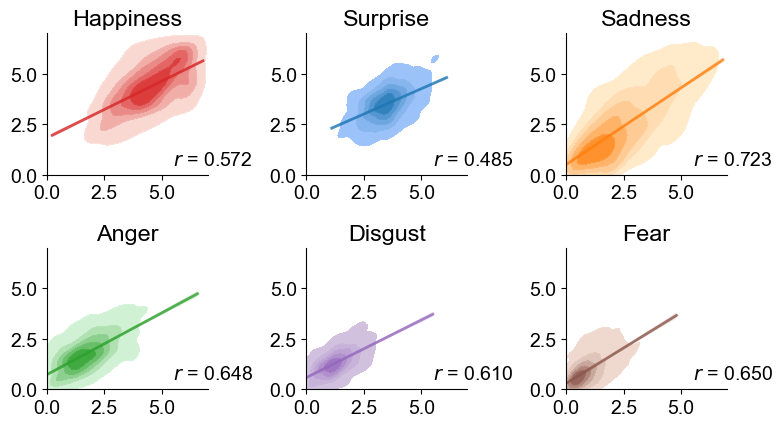

In [32]:
import seaborn as sns
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
emos = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]
colors = ['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']
gradients = [
    LinearSegmentedColormap.from_list('grad1', ['#FFF0E9', colors[0]]),  # Red
    LinearSegmentedColormap.from_list('grad2', ['#A6C8FF', colors[1]]),  # Blue
    LinearSegmentedColormap.from_list('grad3', ['#FFF1D6', colors[2]]),  # Orange
    LinearSegmentedColormap.from_list('grad4', ['#E0F9E4', colors[3]]),  # Green
    LinearSegmentedColormap.from_list('grad5', ['#D5C6E0', colors[4]]),  # Purple
    LinearSegmentedColormap.from_list('grad6', ['#F5E1D7', colors[5]])   # Brown
]

# orange_cmap = LinearSegmentedColormap.from_list('custom orange',['#FFF0E9', '#F48849'])
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 14
plt.figure(figsize=(8,4.5))
for i in range(6):
    # Concatenate preds_smoothed1 and preds_smoothed2 for each emotion
    data = np.concatenate((np.expand_dims(preds_smoothed1[:, i], 1), np.expand_dims(preds_smoothed2[:, i], 1)), 1)
    
    # Convert the numpy array to a pandas DataFrame
    df = pd.DataFrame(data, columns=['x', 'y'])  # Give columns names 'x' and 'y'
    
    ax = plt.subplot(2, 3, i + 1)
    
    # First KDE plot with filled contours
    sns.kdeplot(data=df, x='x', y='y', cmap=gradients[i], fill=True, alpha=1.0, levels=6)
    
    # Second KDE plot without filling and with lines
    sns.kdeplot(data=df, x='x', y='y', cmap=gradients[i], fill=False, levels=6, linewidths=0.5, alpha=0.6)
    
    sns.regplot(data=df, x='x', y='y', scatter=False, line_kws={'color': colors[i], 'lw': 2, 'alpha': 0.8})
    
    plt.title(emos[i])
    plt.xticks(np.arange(0,7,2.5))
    plt.yticks(np.arange(0,7,2.5))
    plt.xlim([0,7])
    plt.ylim([0,7])
    plt.xlabel('')
    plt.ylabel('')
    plt.text(5.5,0.5,'$r$ = %.3f' % rs[i])
    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/inter_group_reliability2.svg', bbox_inches='tight', dpi=300)
plt.show()